# 📚 StudySmart — Your Personal Study Planner

## Introduction

Meet Anna. She has four exams coming up, a part-time job, and a gym routine she's not willing to drop. She knows she needs to study - she just has no idea how to fit it all in. Sound familiar?

Before an exam season, Anna either wings her study schedule and hopes for the best, or spends hours building a colour-coded spreadsheet that never ends up being realistic or efficient. 

StudySmart is a Python package and Dash web application built for students like Anna. You enter your exam dates, how many hours each subject needs, and when you're unavailable. Then, it builds your personalised study schedule automatically. 

You get a personalised study plan and study tips, with an optional spaced repetition mode, which is inspired by Ebbinghaus' forgetting curve (1885). When you are ready, you can export the whole schedule straight to Google Calendar.

No more guessing and calculating — simply download the package and start studying and planning smarter.

Anna opens StudySmart, enters her four exams, blocks out her work shifts and gym sessions, and clicks a button to generate a schedule. In under a minute she has a realistic, colour-coded study plan that fits her actual life — exported straight to her Google Calendar and ready to follow from day one.

StudySmart works as an **advance planner** — set it up at the start of your exam period.


## Package Structure

StudySmart consists of three components:

- **`schedule.py`** — the core scheduling engine. `build_schedule` takes a list  of exams, a start date, and a dictionary of blocked hours,and builds a personalised study schedule in two passes. First, total hours are divided equally across topics and distributed across available days up to a daily target. A second pass then fills  any leftover capacity in day order, ensuring no available time is wasted. If an exam has more hours than the available days allow, all topics are reduced proportionally and a warning is issued so the user knows to start earlier.Topics are always studied in order — Chapter 1 is finished before Chapter 2 begins. Optionally, 30-minute spaced repetition review sessions are scheduled at 1, 3, 7, and 14 days after the last study session for each topic, based on the Ebbinghaus forgetting curve (Ebbinghaus, 1885; 
Murre & Dros, 2015). Reviews are lowest priority and only use leftover time after all initial study is scheduled.

- **`google_calendar.py`** — Google Calendar integration. Users can import their existing calendar events as commitments, and export their generated schedule back to Google Calendar as all-day events.

- **`app.py`** — a three-tab Dash web app that wraps the scheduling engine in an interactive browser-based interface. No coding required — students can add exams, manage commitments, generate schedules, and export everything to Google Calendar in a few clicks.

## Core Functions — Live Demo

### `build_schedule` — Live Demo

The example below shows `build_schedule` with two exams, a commitment on June 3rd 
blocking 4 hours, and spaced repetition enabled. The function returns a DataFrame 
with the full schedule and a list of any warnings.

In [9]:
from datetime import date
from study_smart.schedule import build_schedule, generate_tips

# Example: two exams, one commitment
exams = [
    {"name": "Statistics", "date": date(2026, 6, 10), "hours": 14,
     "topics": ["Chapter 1", "Chapter 2"]},
    {"name": "Neuroimaging", "date": date(2026, 6, 15), "hours": 10,
     "topics": ["Lecture 1", "Lecture 2"]},
]

commitments = {date(2026, 6, 3): 4}  # 4 hours blocked on June 3rd

schedule, warnings = build_schedule(
    exams,
    start_date=date(2026, 6, 1),
    commitments=commitments,
    spaced_repetition=True
)

print("Warnings:", warnings)
schedule

Warnings: ['Some topics could not get all 4 spaced repetition reviews. Consider starting earlier to allow more review time.']


,date,subject,hours,type
0,2026-06-01,Chapter 1,1.5,initial
1,2026-06-02,Chapter 1,1.5,initial
2,2026-06-03,Chapter 1,1.5,initial
3,2026-06-04,Chapter 1,1.5,initial
4,2026-06-05,Chapter 1,1.0,initial
5,2026-06-06,Chapter 2,1.5,initial
6,2026-06-07,Chapter 2,1.5,initial
7,2026-06-08,Chapter 2,1.5,initial
8,2026-06-09,Chapter 2,1.5,initial
9,2026-06-09,Chapter 2,1.0,initial


### `generate_tips` — Live Demo

`generate_tips` analyses the generated schedule and returns personalised, 
evidence-based tips depending on how much time is left per exam and how 
heavily loaded each day is.

The example below constructs a scenario that triggers all three tip types at once:
- **Active recall** — Statistics exam is only 5 days away

- **Deep understanding** — Neuroimaging exam is 20 days away 
 
- **Light load** — only 1 hour scheduled per day on average

In [3]:
# Demo showing all three tips at once:
# - "Statistics" is in 5 days → triggers active recall tip (≤7 days)
# - "Neuroimaging" is in 20 days → triggers deep understanding tip (≥14 days)  
# - only 1 hour scheduled per day on average → triggers light load tip (<3.5h/day)

import pandas as pd

all_tips_schedule = pd.DataFrame({
    "date": [date(2026, 6, 1), date(2026, 6, 2), date(2026, 6, 3)],
    "subject": ["Statistics", "Neuroimaging", "Statistics"],
    "hours": [1.0, 1.0, 1.0]
})

all_tips_exam_dates = {
    "Statistics": date(2026, 6, 6),    # 5 days away → active recall
    "Neuroimaging": date(2026, 6, 21)  # 20 days away → deep understanding
}

all_tips = generate_tips(
    all_tips_schedule,
    all_tips_exam_dates,
    start_date=date(2026, 6, 1),
    default_hours=7
)

for tip in all_tips:
    print(tip)
    print()

Only 5 days left for 'Statistics'. Use active recall — test yourself rather than re-reading notes. (Roediger & Karpicke, 2006)

20 days until 'Neuroimaging' — aim for deep understanding. The deeper you process information, the better your memory retention. (Craik & Lockhart, 1972)

Your average study load is only 1.0h/day — you have plenty of time! Consider increasing hours per topic or adding more practice sessions to strengthen retention.



## Installation & Setup

To get started, clone the repository and install the package:

```bash
git clone https://github.com/Programming-The-Next-Step-2026/StudySmart
cd StudySmart
pip install -e .
```

Then launch the app:

```bash
python src/study_smart/app.py
```

Open your browser at `http://127.0.0.1:8050`, and you can start setting up your schedule!

If you would like to use **Google Calendar import**, it requires additional setup — see the README for instructions on getting your own `credentials.json`.

> **Note:** Restarting the app requires stopping the server completely. Press **Ctrl+C** in the terminal to stop it, then run the command again. Simply refreshing the browser will not reset your data.

## Dependencies

| Requirement | Version |
|-------------|---------|
| Python | ≥ 3.12 |
| pandas | ≥ 2.2.2 |
| plotly | ≥ 5.24.1 |
| dash | ≥ 2.4.0 |
| dash-bootstrap-components | ≥ 2.0.4 |
| openpyxl | ≥ 3.1.5 |
| google-auth | ≥ 2.52.0 |
| google-auth-oauthlib | ≥ 1.4.0 |
| google-api-python-client | ≥ 2.196.0 |




## User Flowchart

The diagram below shows the steps Anna takes when using the app:

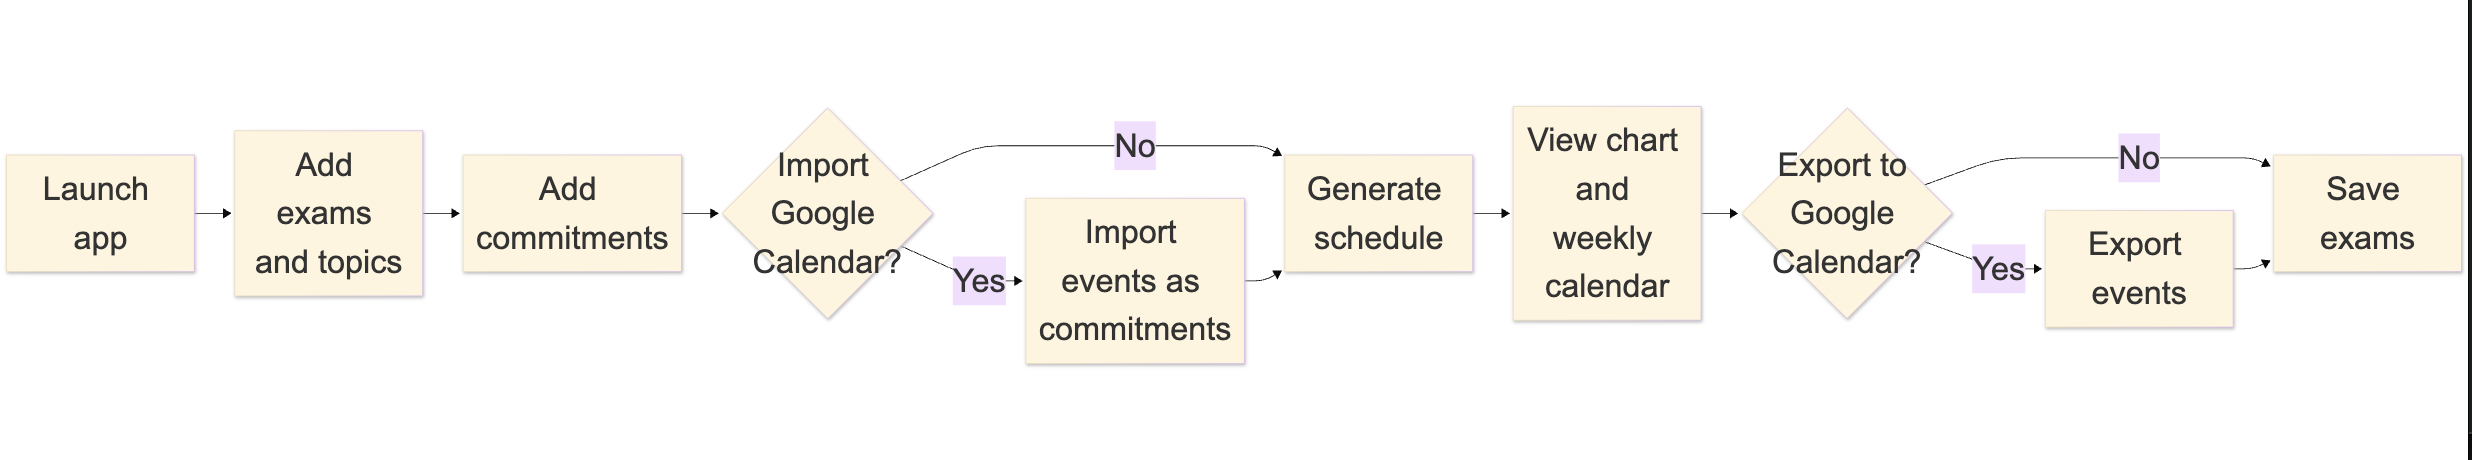


## Software Flowchart

The software flowcharts below show the corresponding software actions.

### Software Flowchart — Main Functions

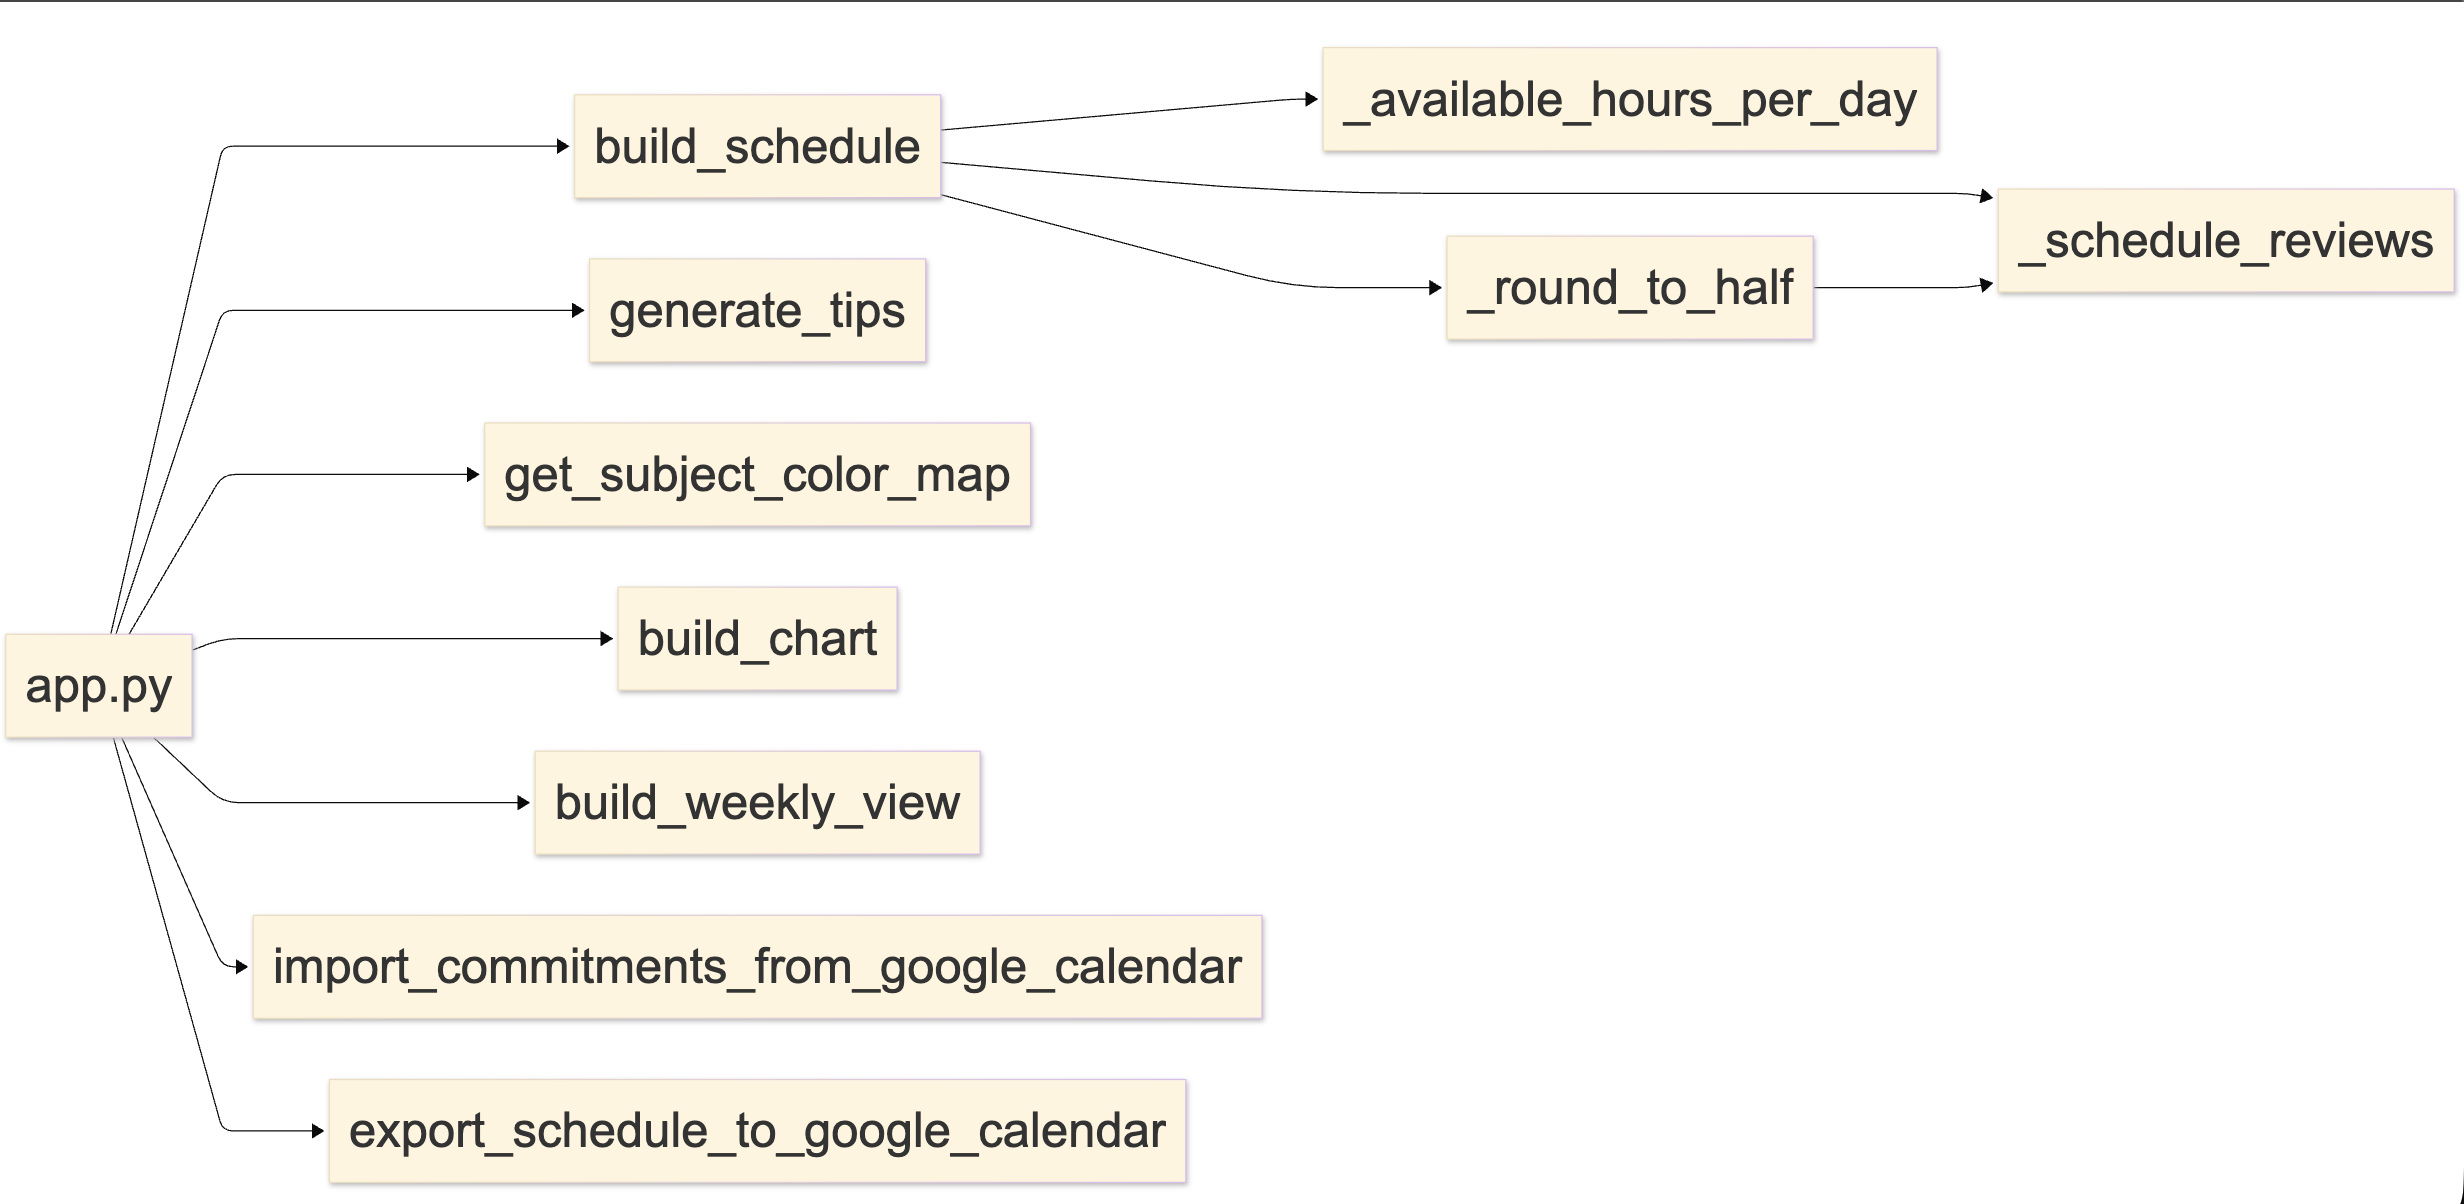


### build_schedule — Internal Algorithm

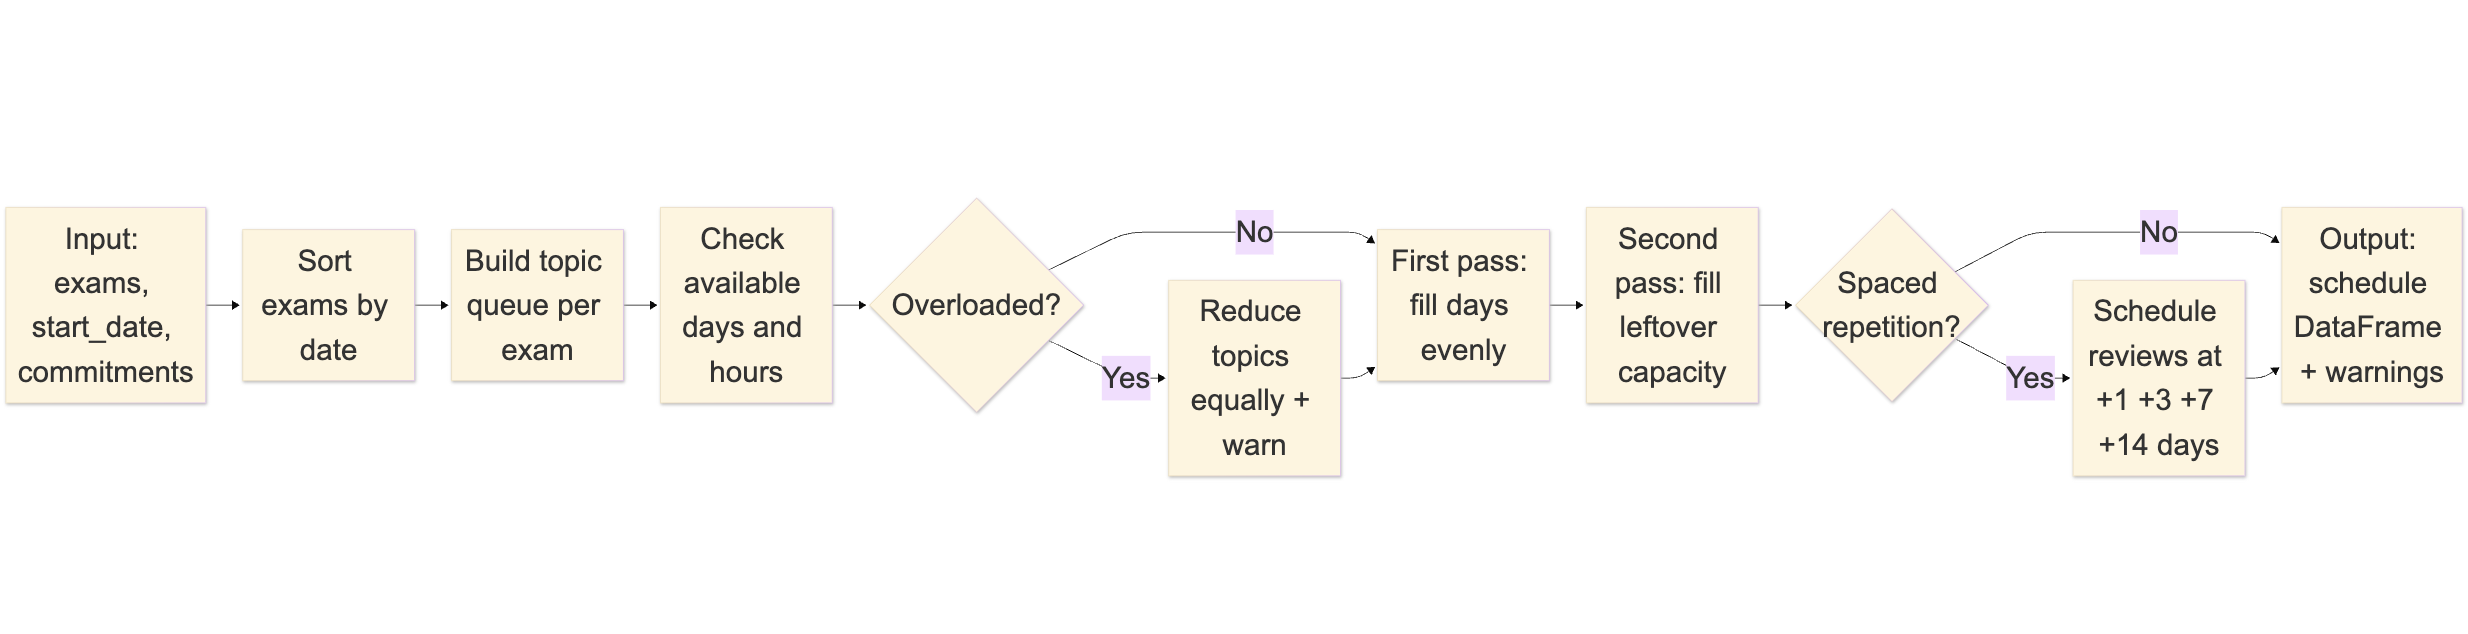

## App layout

StudySmart has 3 tabs, each handling a different part of the planning process:

1. **📚 My Exams** — add your exams, dates of exams, hours needed for each exam, and you can optionally add topics (e.g.,Chapter 1, Chapter 2)

2. **⏰ My Schedule** — add commitments when you are busy and import from Google Calendar  

3. **🗓️ Study Plan** — generate and view your schedule and study tips

`build_schedule` distributes your study hours evenly across available days, respects your commitments, and ensures all topics are covered before the exam. It also ensures that you first finish with Topic 1 before moving on to Topic 2. 

## **How To Use It?**

## **📚 My Exams** tab

Enter:
- **Exam name** (e.g. Statistics)

- **Exam date**

- **Hours needed** to study

- **Topics** (optional, comma separated — e.g. Chapter 1, Chapter 2, Chapter 3)

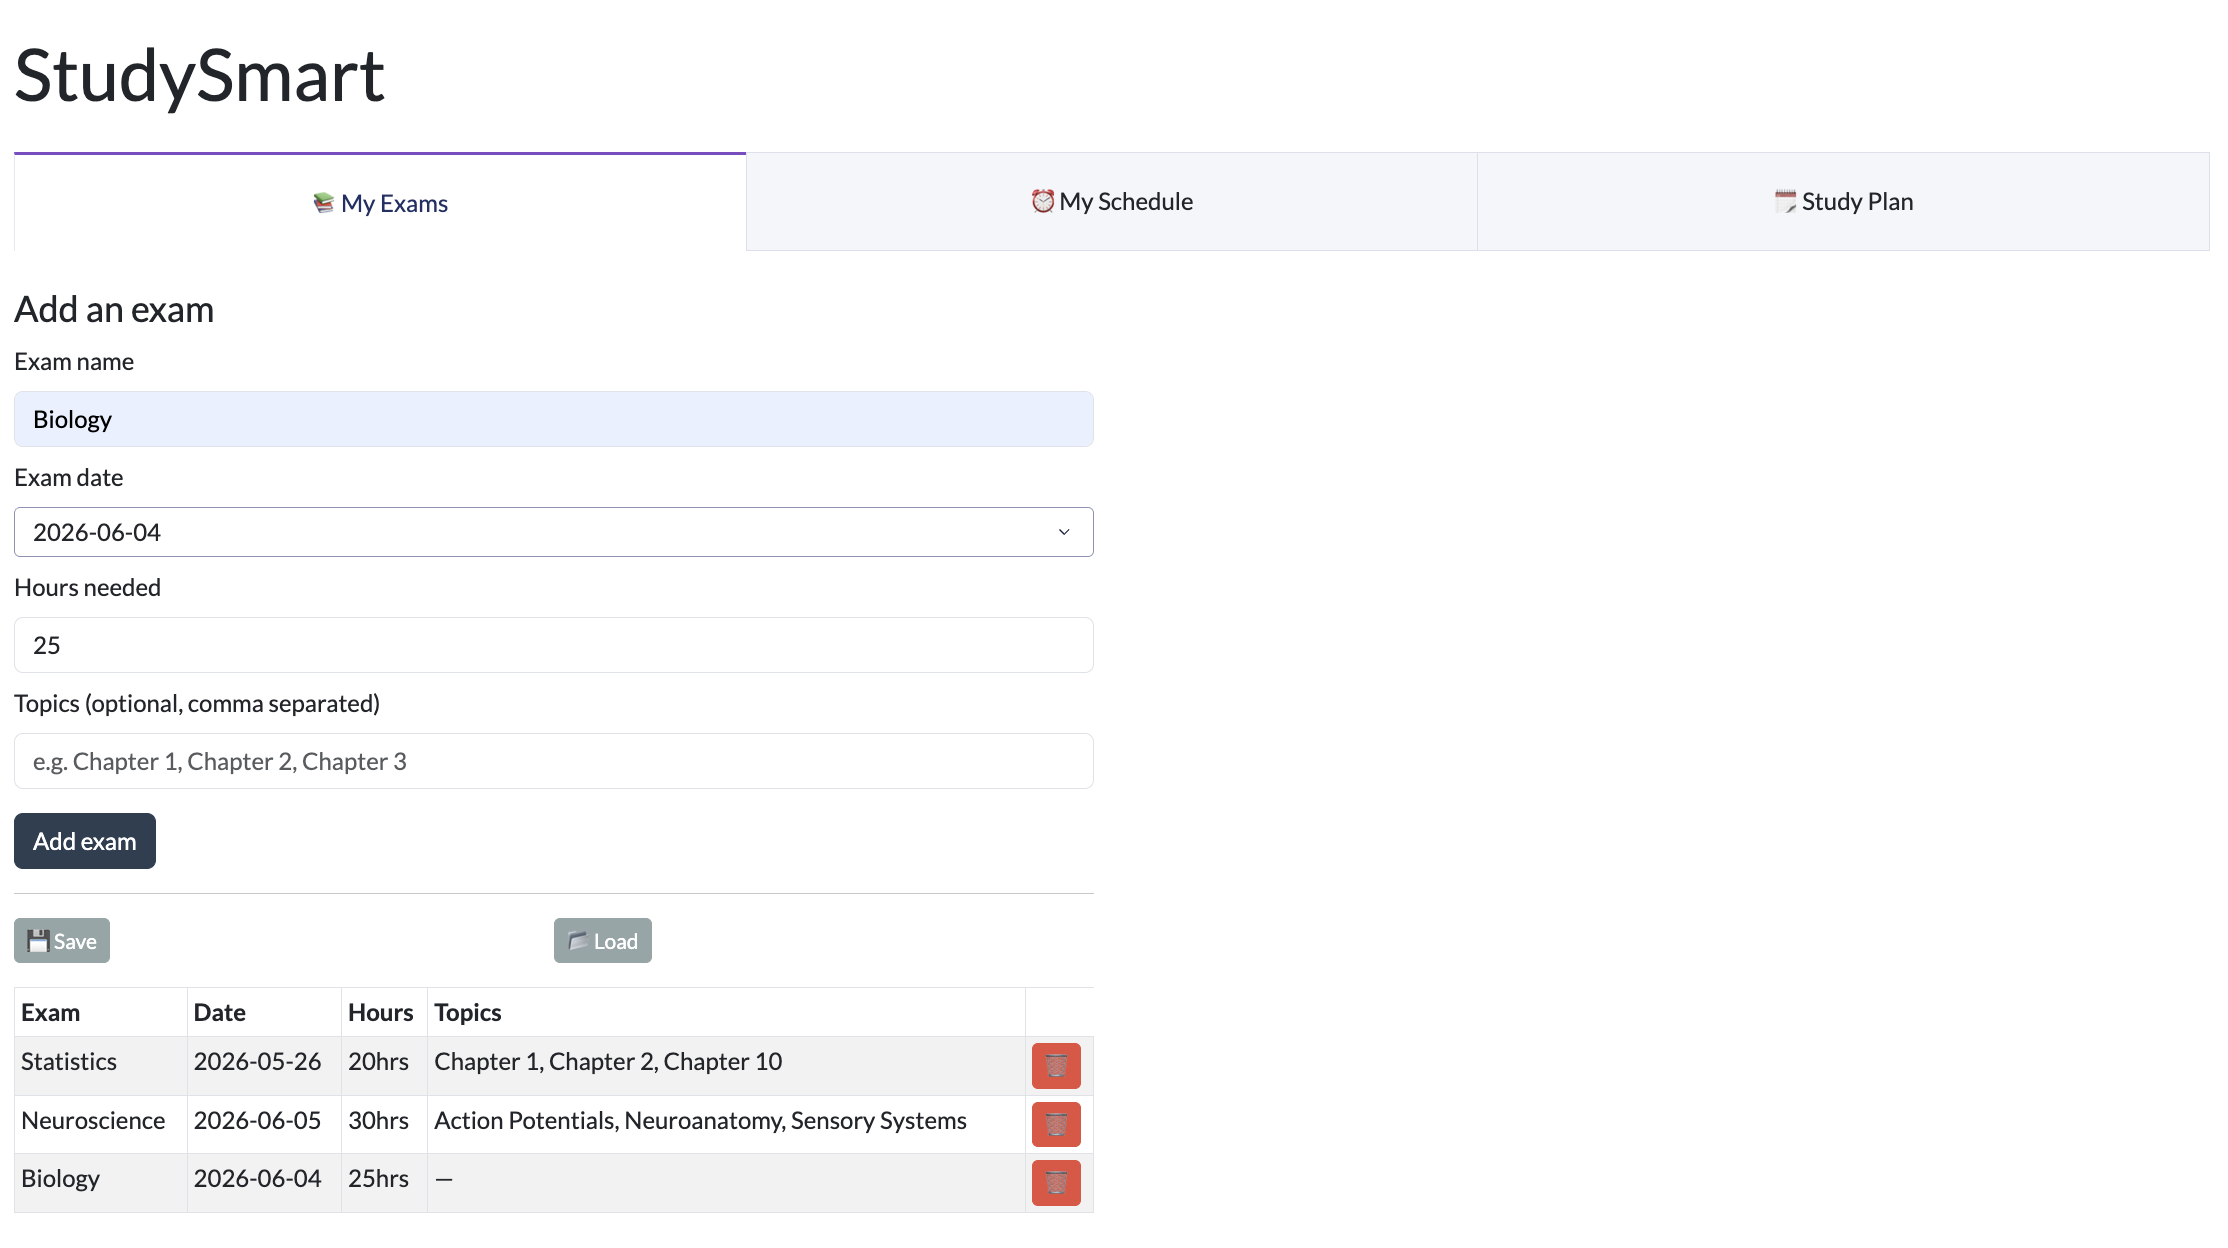

StudySmart will give a warning and prevent you from accidentally adding duplicate exam names or topic names across exams, keeping your schedule unambiguous.

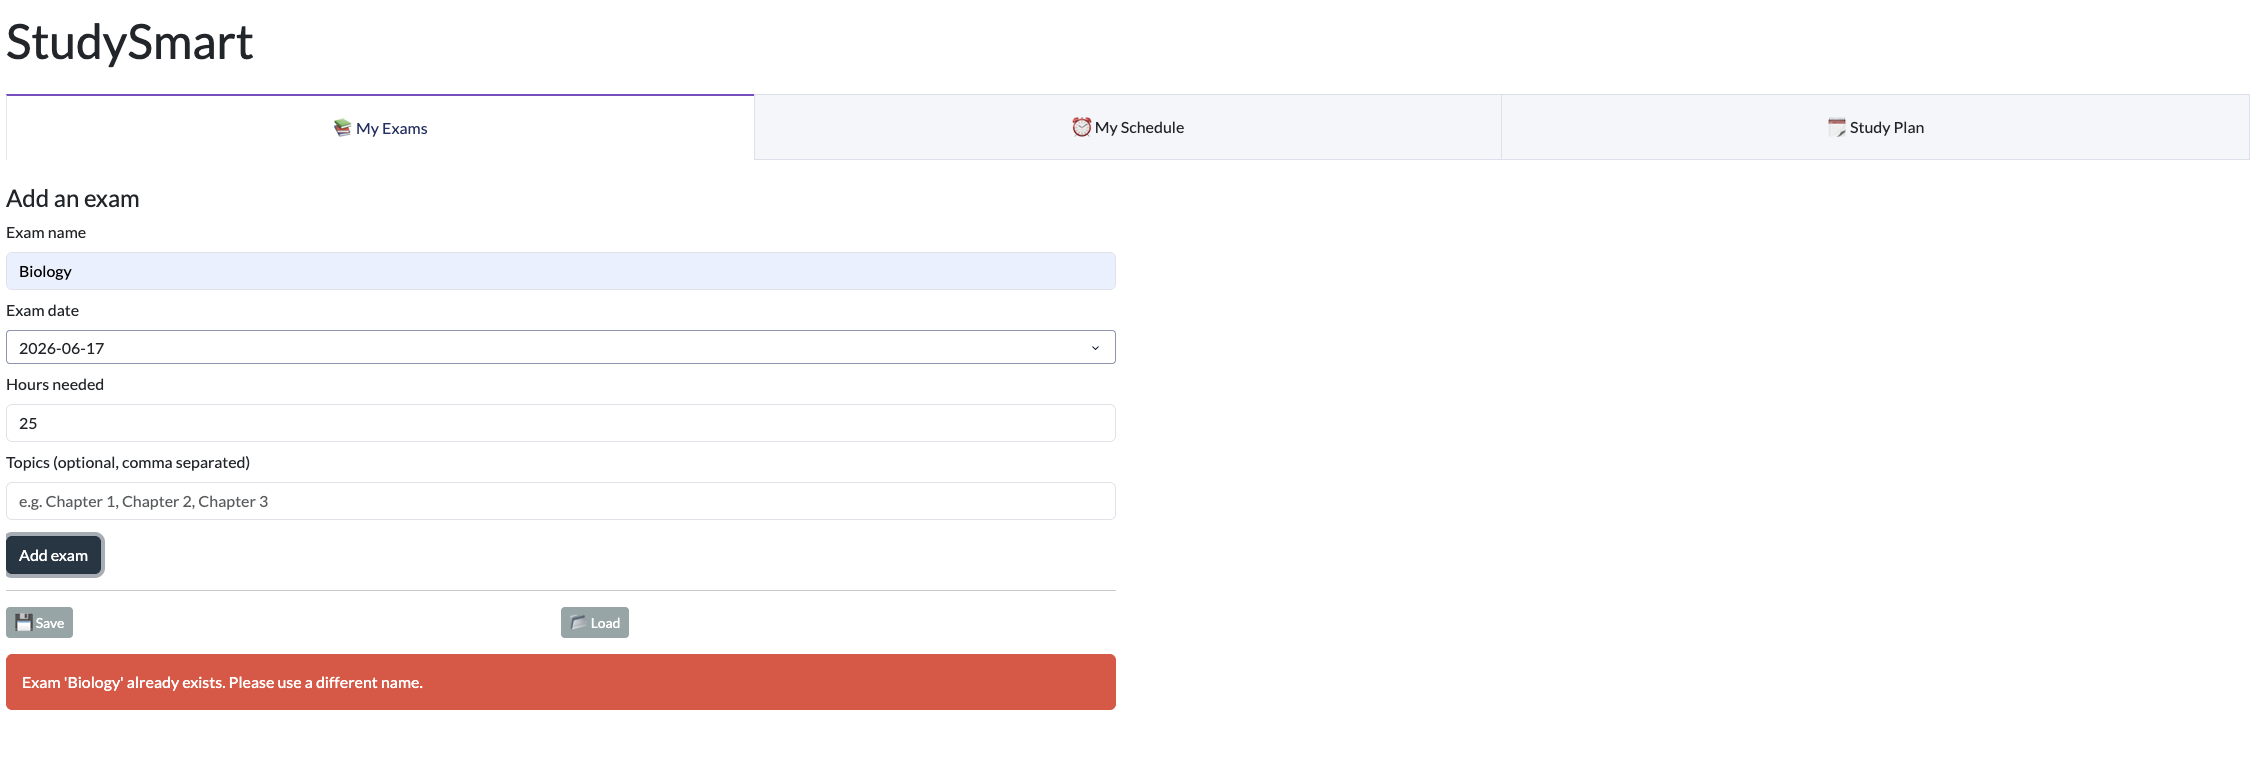

### **Saving and Loading**

To not lose your exam inputs when you close the app, use the **💾 Save** button in the **📚 My Exams** tab to save your exams' information to an Excel file (`my_studysmart.xlsx`), which is saved inside your StudySmart folder, and reload it next time with clicking **📂 Load** button in the same tab.


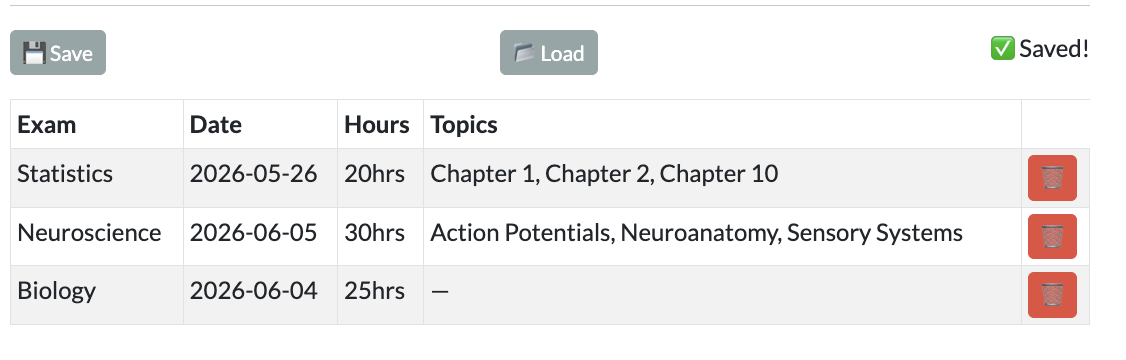

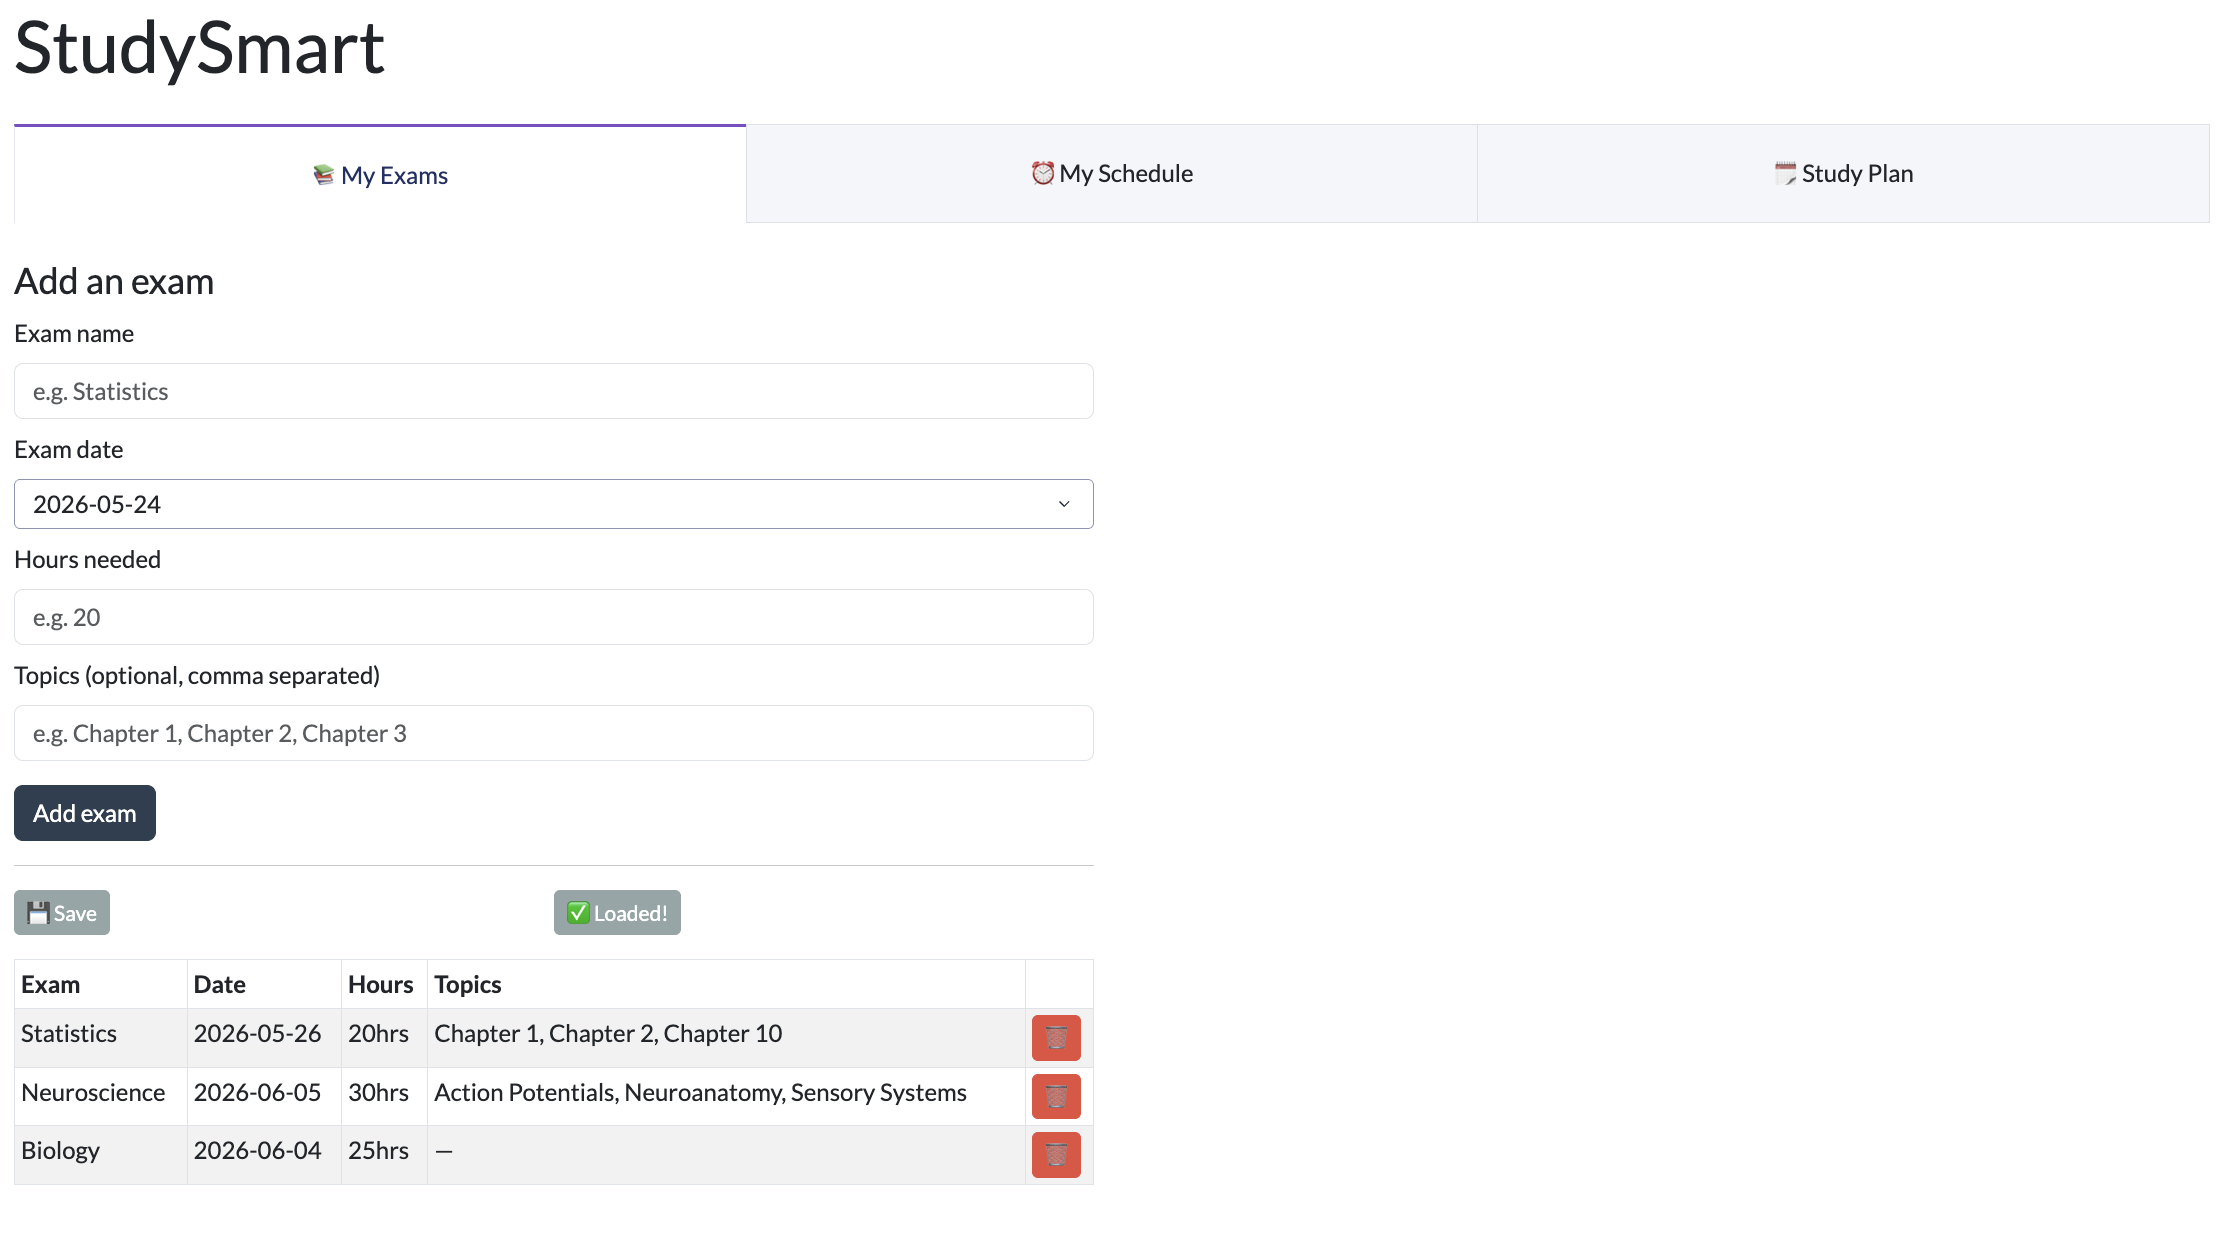

## **⏰ My Schedule** tab

Block out the times you are unavailable:

#### Under **Schedule settings** #### 
-  put **default study hours per day** you are willing to spend studying (**default = 7**, click the arrows up and down to adjust)

-  add the date you want to **start studying from**

#### Under **Add a commitment** ####
- Add individual commitments (date, name, hours blocked)

- Or click **Import from Google Calendar** to automatically import all your events from Google Calendar

- Click a  **🗑️ delete button** to remove a commitment if you do not wish to take it into account in your schedule


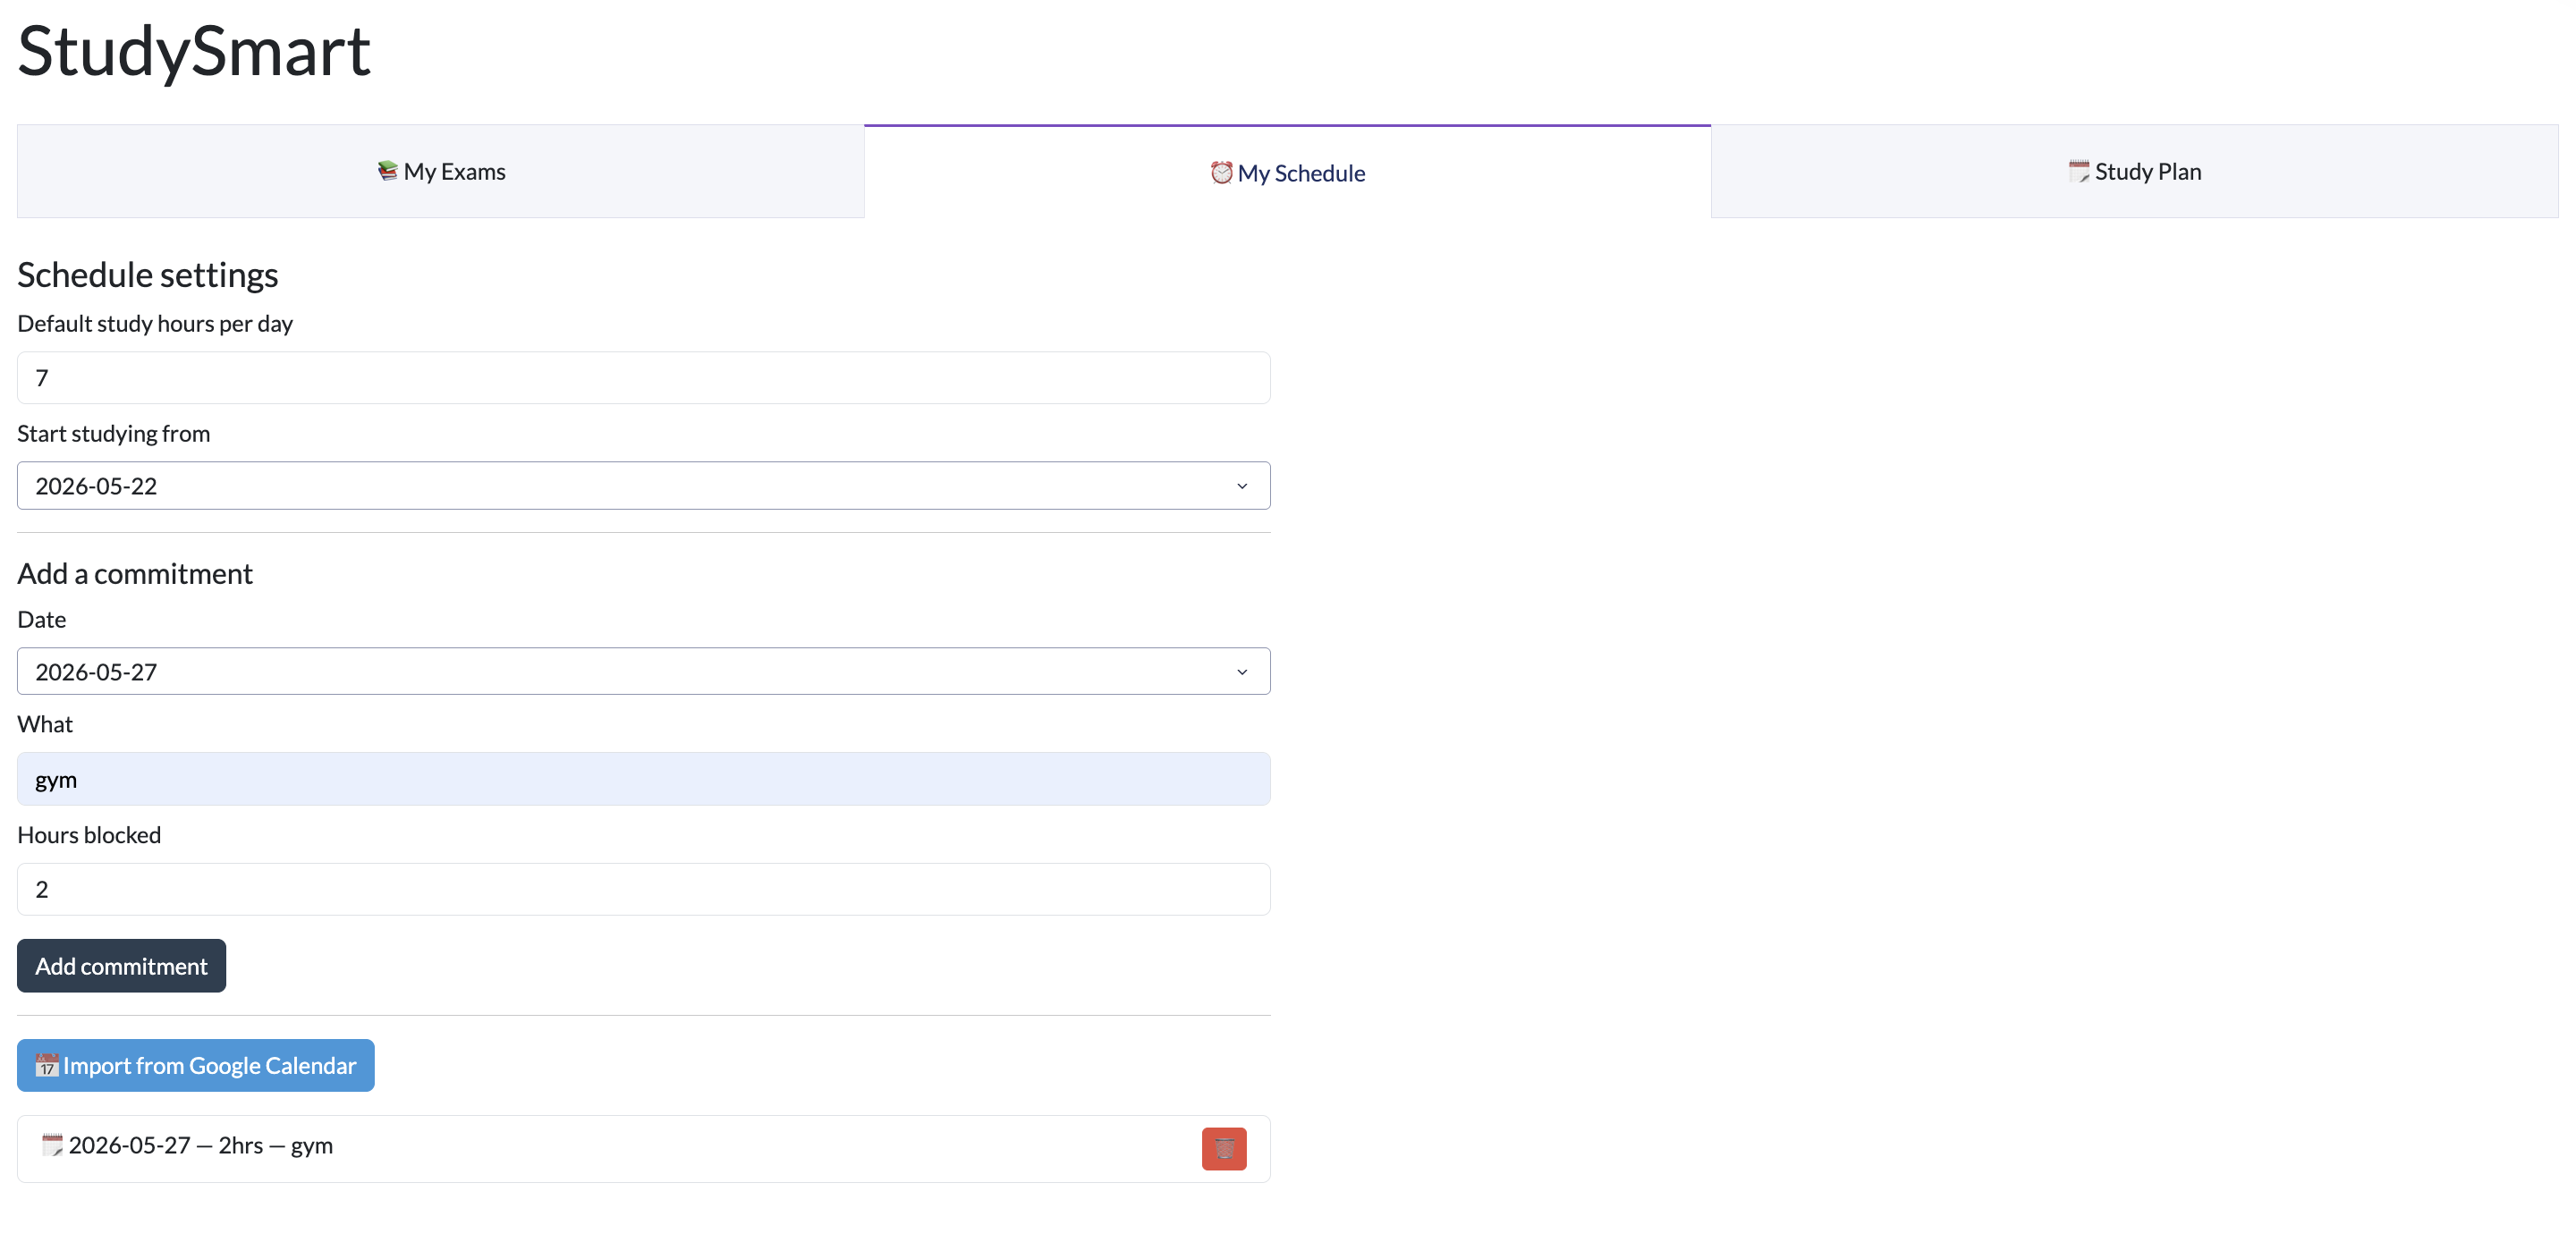



## **🗓️ Study Plan** tab

### **Spaced Repetition** (Optional)

Toggle **Use spaced repetition (Ebbinghaus)** 

When enabled, StudySmart schedules 30-minute review sessions at 1, 3, 7, and 14 days after you finish studying each topic — these are the optimal intervals for long-term memory retention, inspired by research of Ebbinghaus (1885) and Murre & Dros (2015).

Reviews are always the lowest priority - they only use leftover time after all initial study sessions are scheduled, so they never crowd out your core (initial) studying sessions. If some review sessions can't fit, a warning is shown at the top of the schedule.



**Not enough room for all spaced repetition reviews?** Only the review sessions that fit are scheduled. You get a warning listing which ones were skipped, so nothing disappears silently.


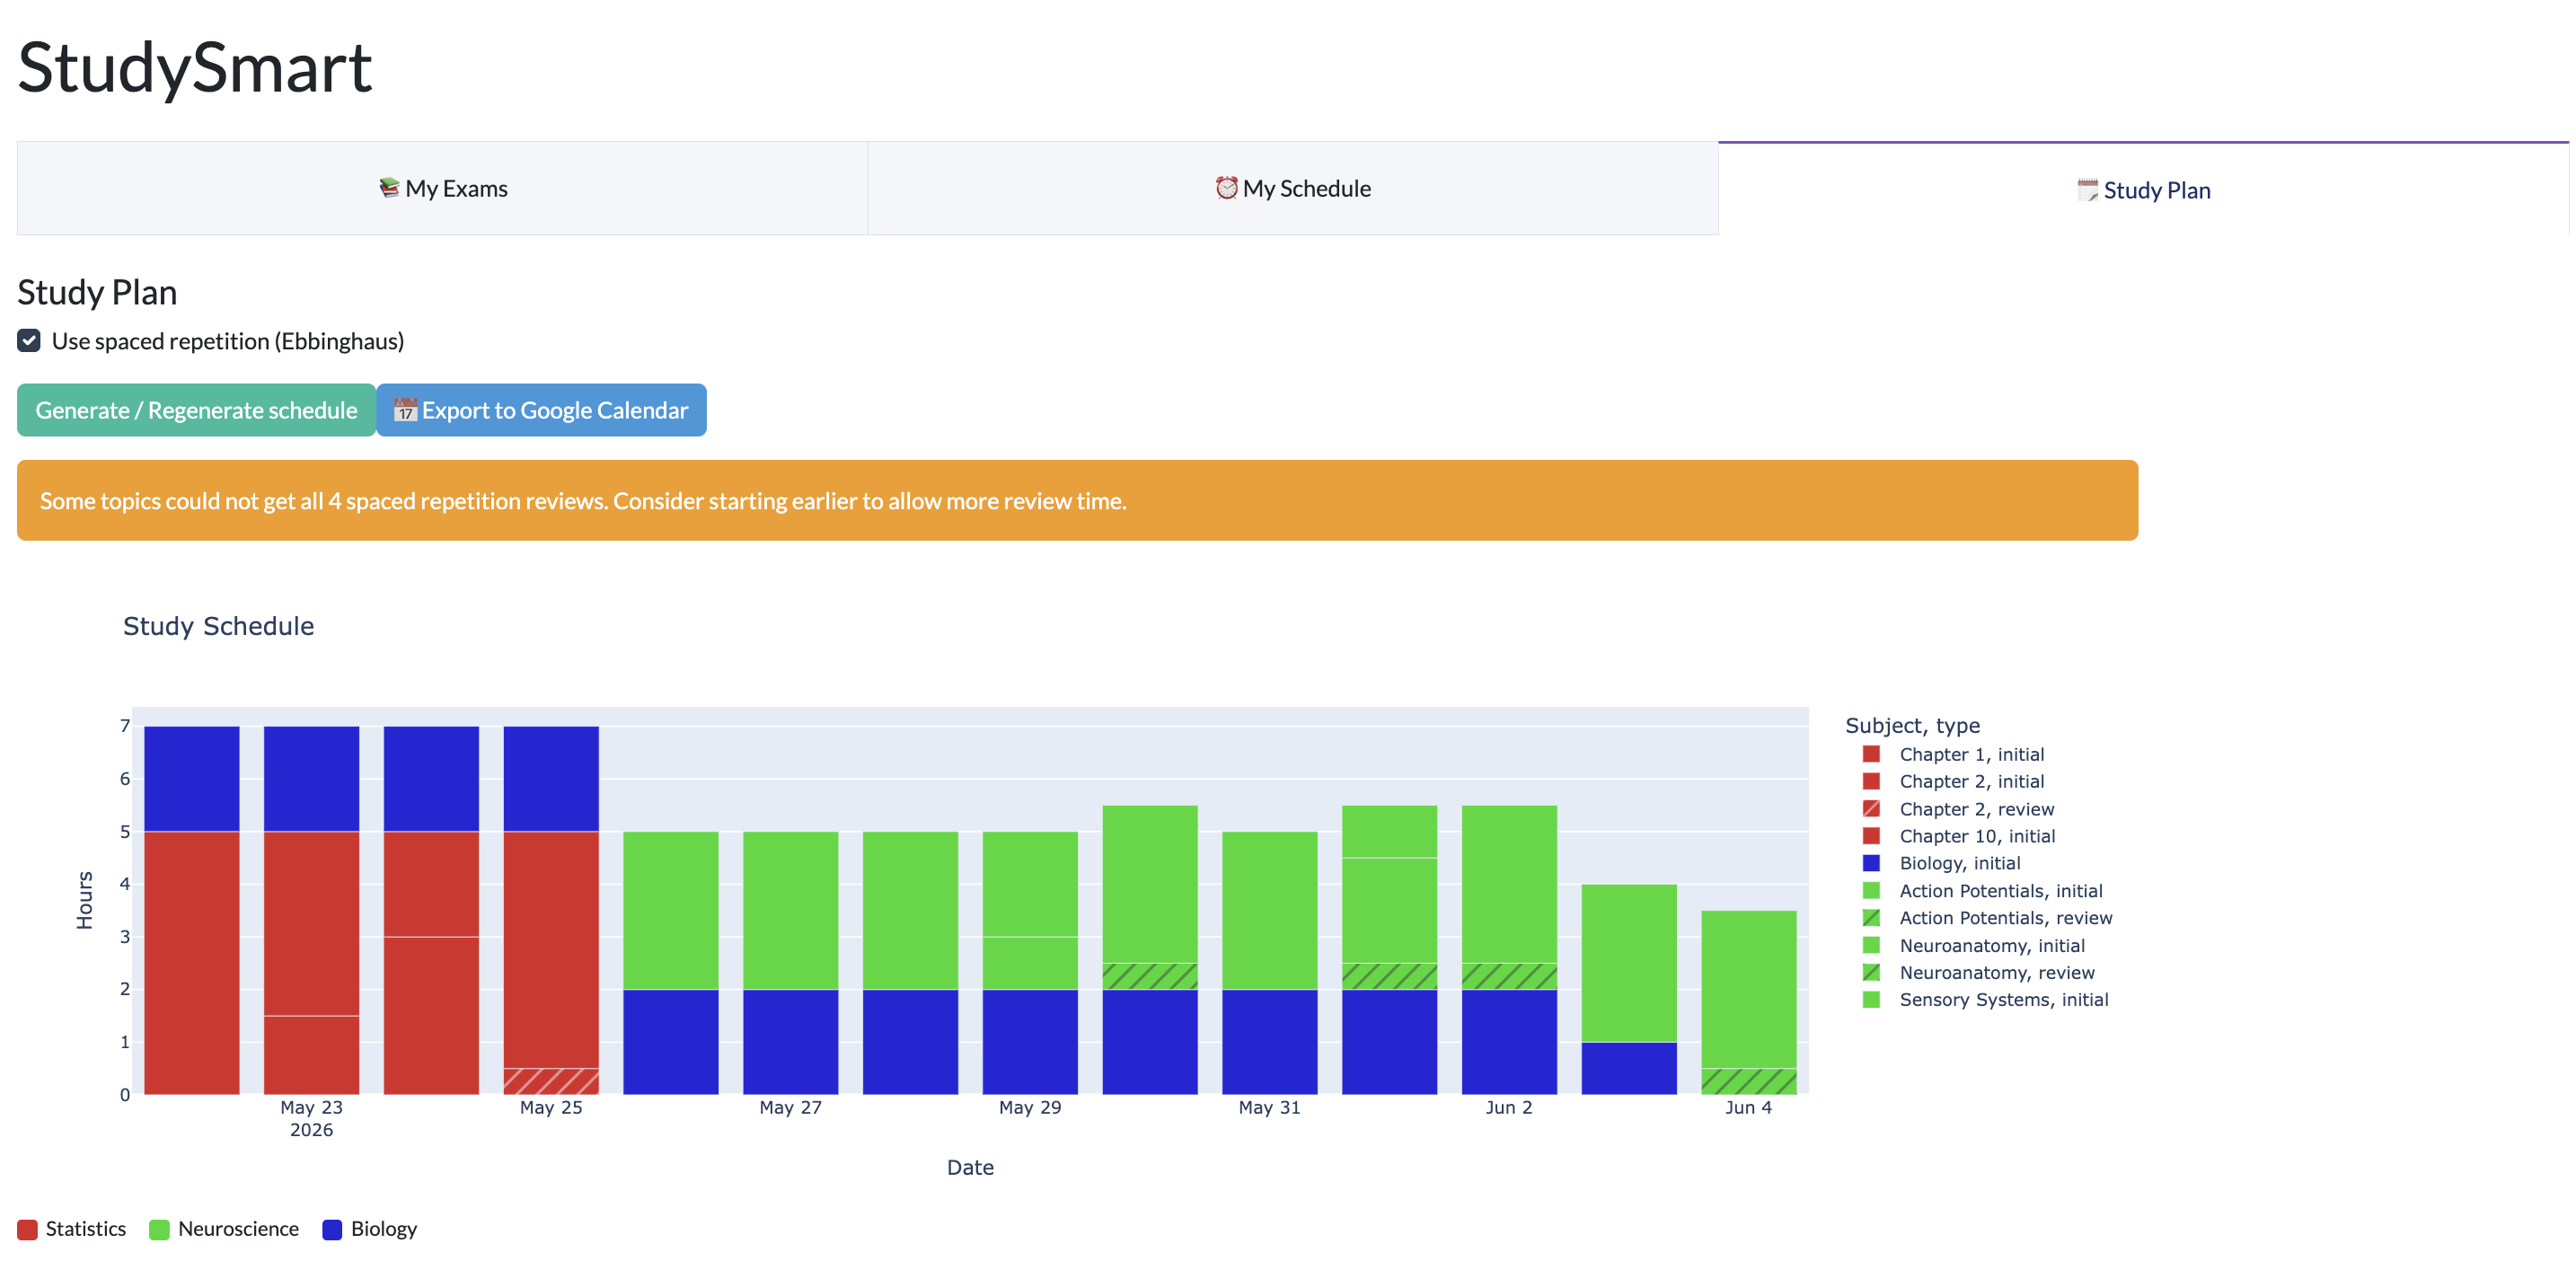
> *Note: This screenshot uses different example data to illustrate the warning message.*

### **Generate Your Schedule**


Click **Generate / Regenerate schedule**.

StudySmart will:

- Distribute study hours evenly across available days

- Study topics in order, finishing one before starting the next

**Not enough time?** StudySmart caps the sessions at the maximum possible and warns you so you can adjust your plan.

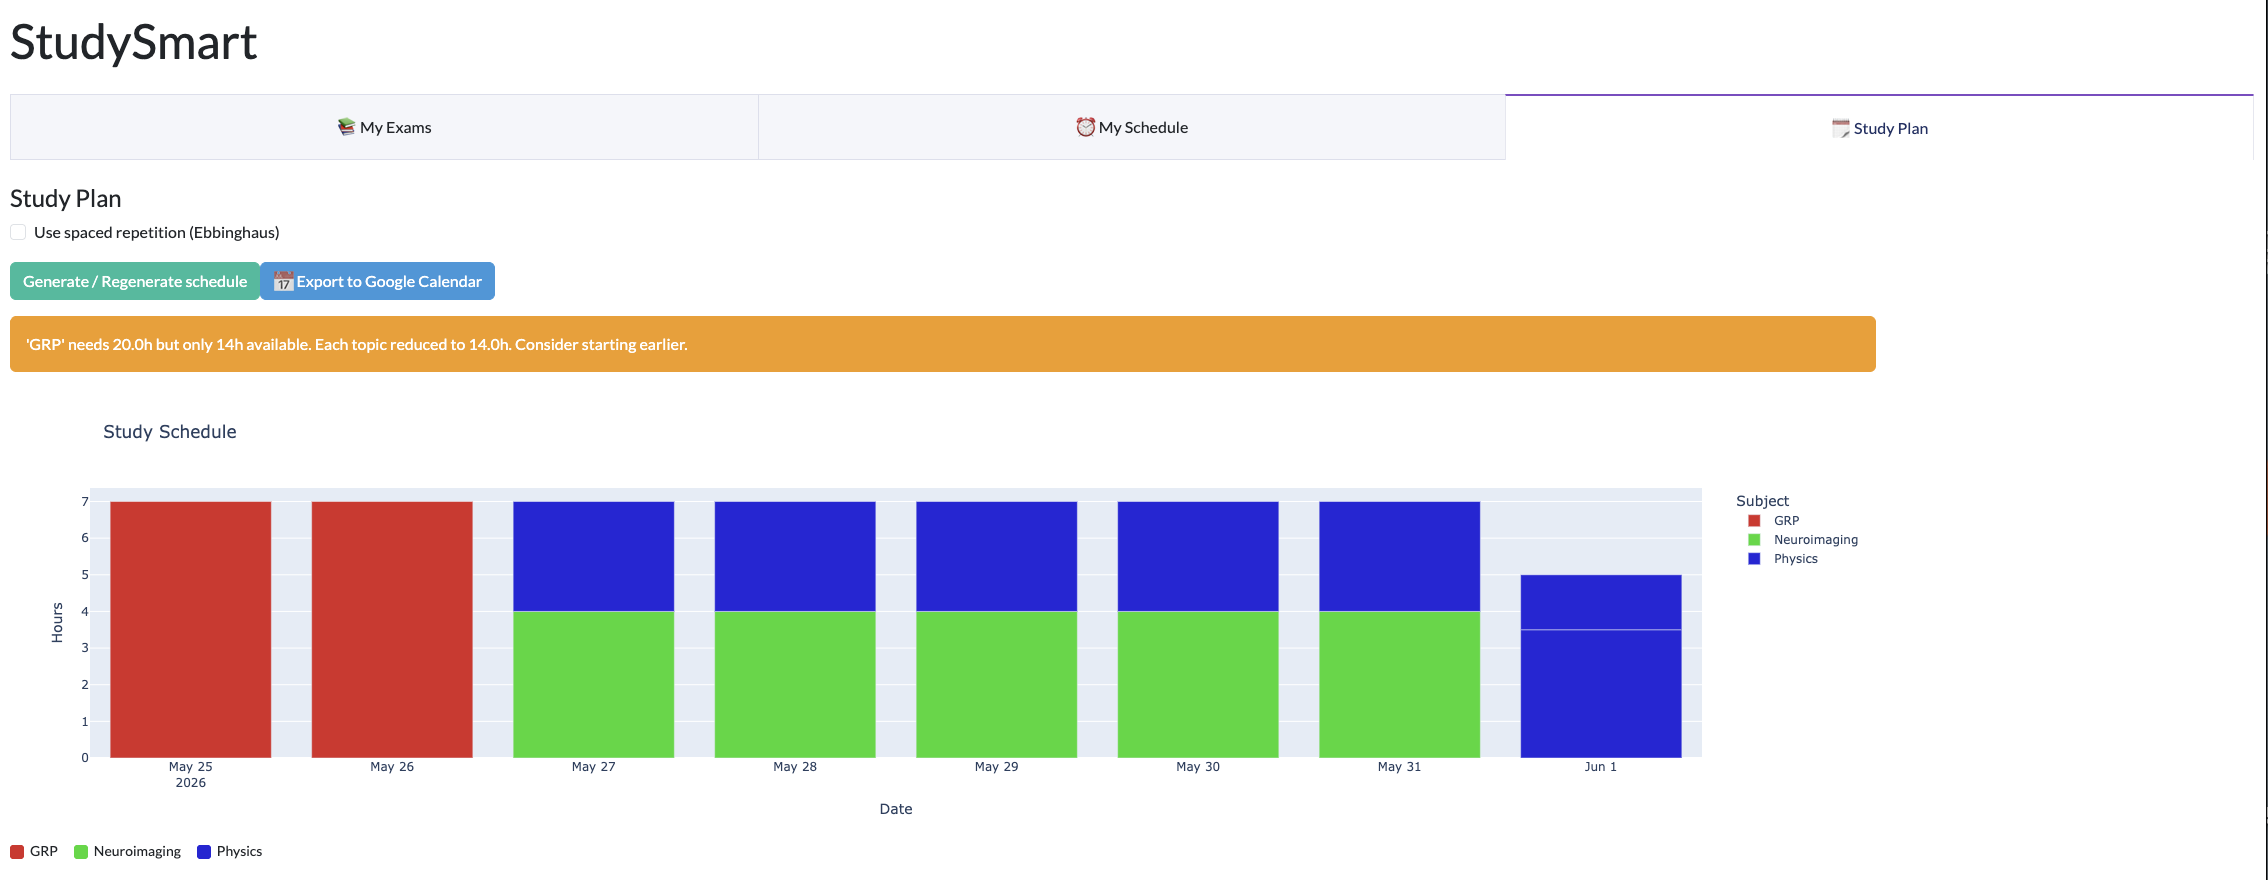

### **Reading Your Schedule**

Your schedule appears in two views — use whichever suits you best:

1. The **colour-coded bar chart** shows your full schedule, with each exam in its own colour.

2. The **weekly calendar view** lets you navigate week by week using the ← Prev and Next → buttons, so you always know exactly what to study that day.

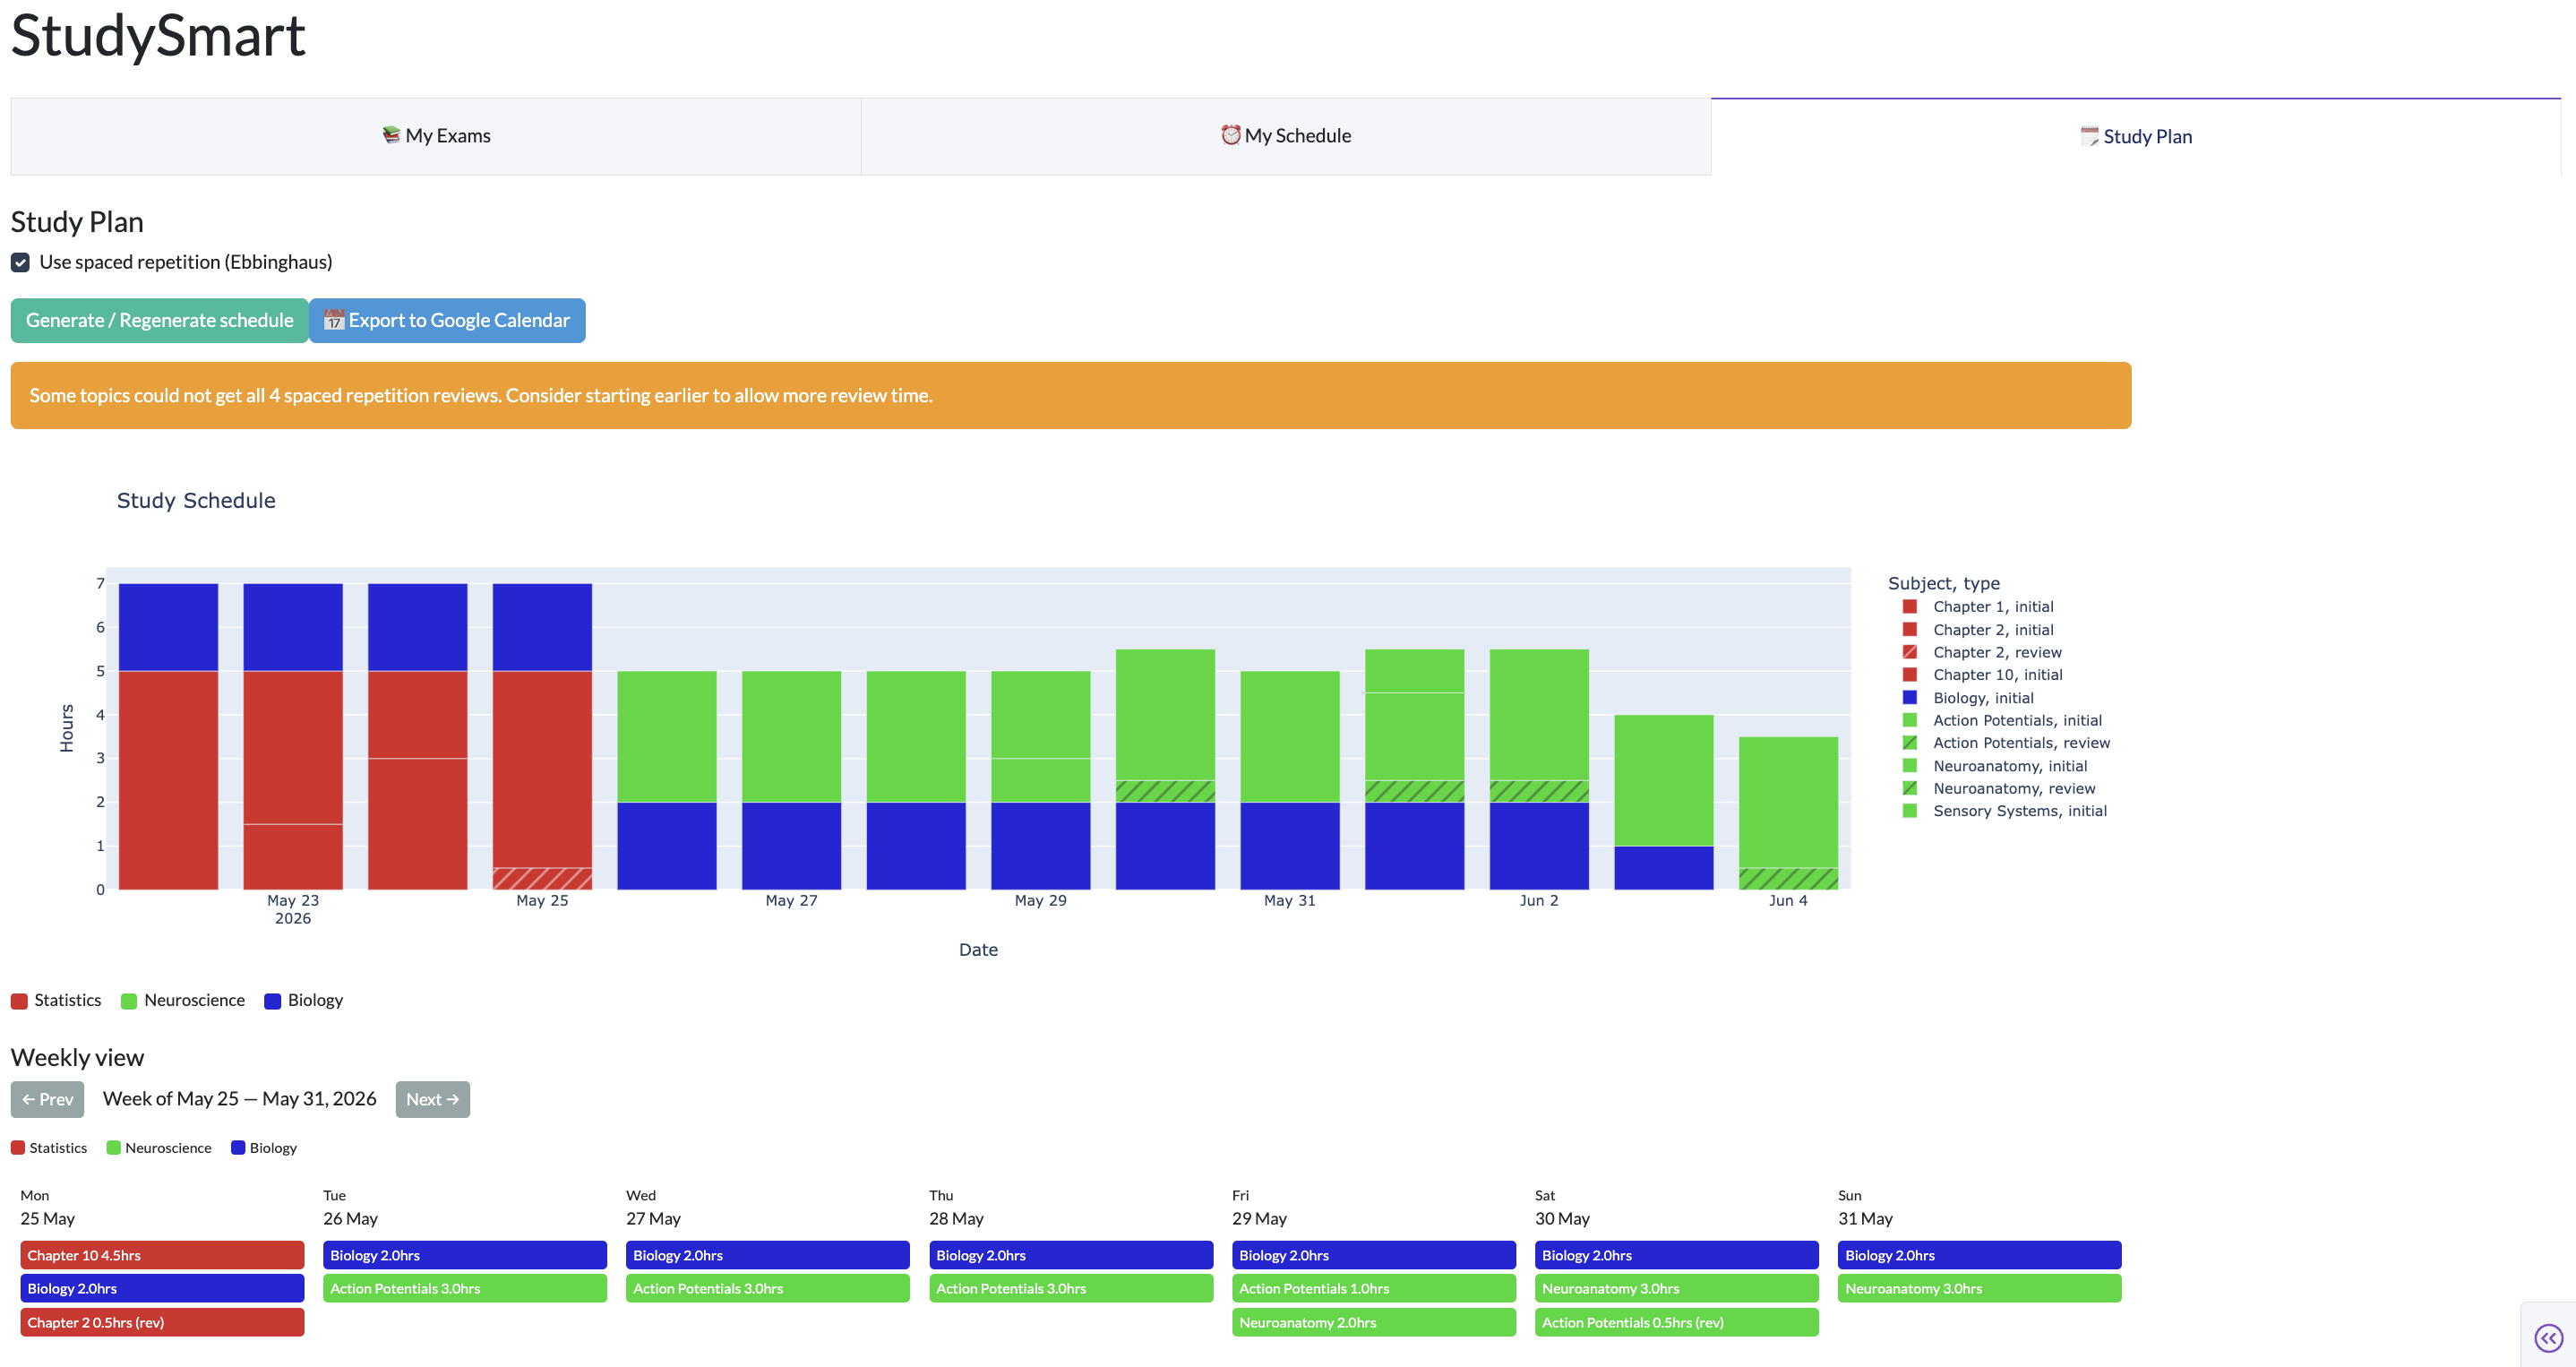

### **Study Tips**

After generating your schedule, StudySmart gives you study tips based on your situation:

- **Little time left?** → Use active recall (Roediger & Karpicke, 2006)

- **Plenty of time?** → Focus on deeper understanding of the topic (Craik & Lockhart, 1972)

- **Light schedule?** → Consider adding more study sessions

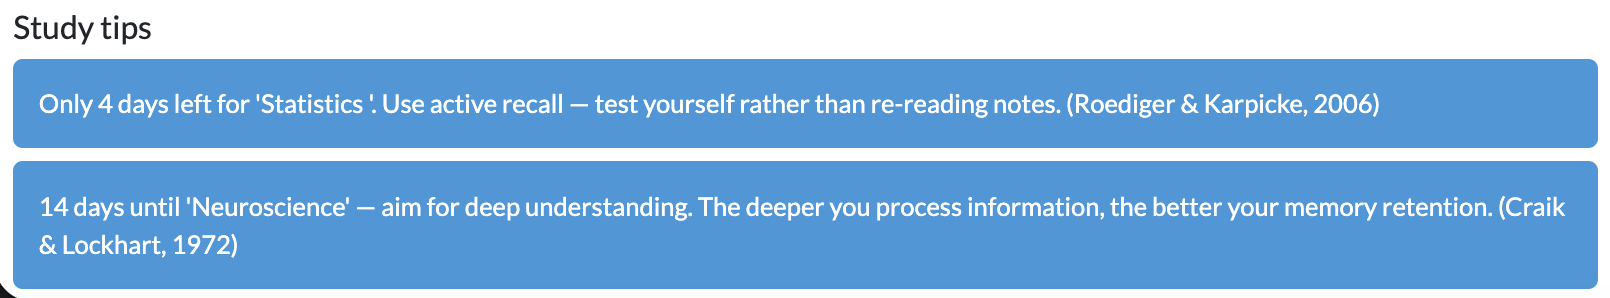

### **Exporting to Google Calendar**

Once your schedule is generated, you can export it directly to your Google Calendar by clicking **Export to Google Calendar** in the **🗓️ Study Plan** tab. Each study session will be added as an all-day event, so you can see your study plan alongside the rest of your schedule.

>  Google Calendar export requires the same OAuth setup as the import feature — see the README for instructions.

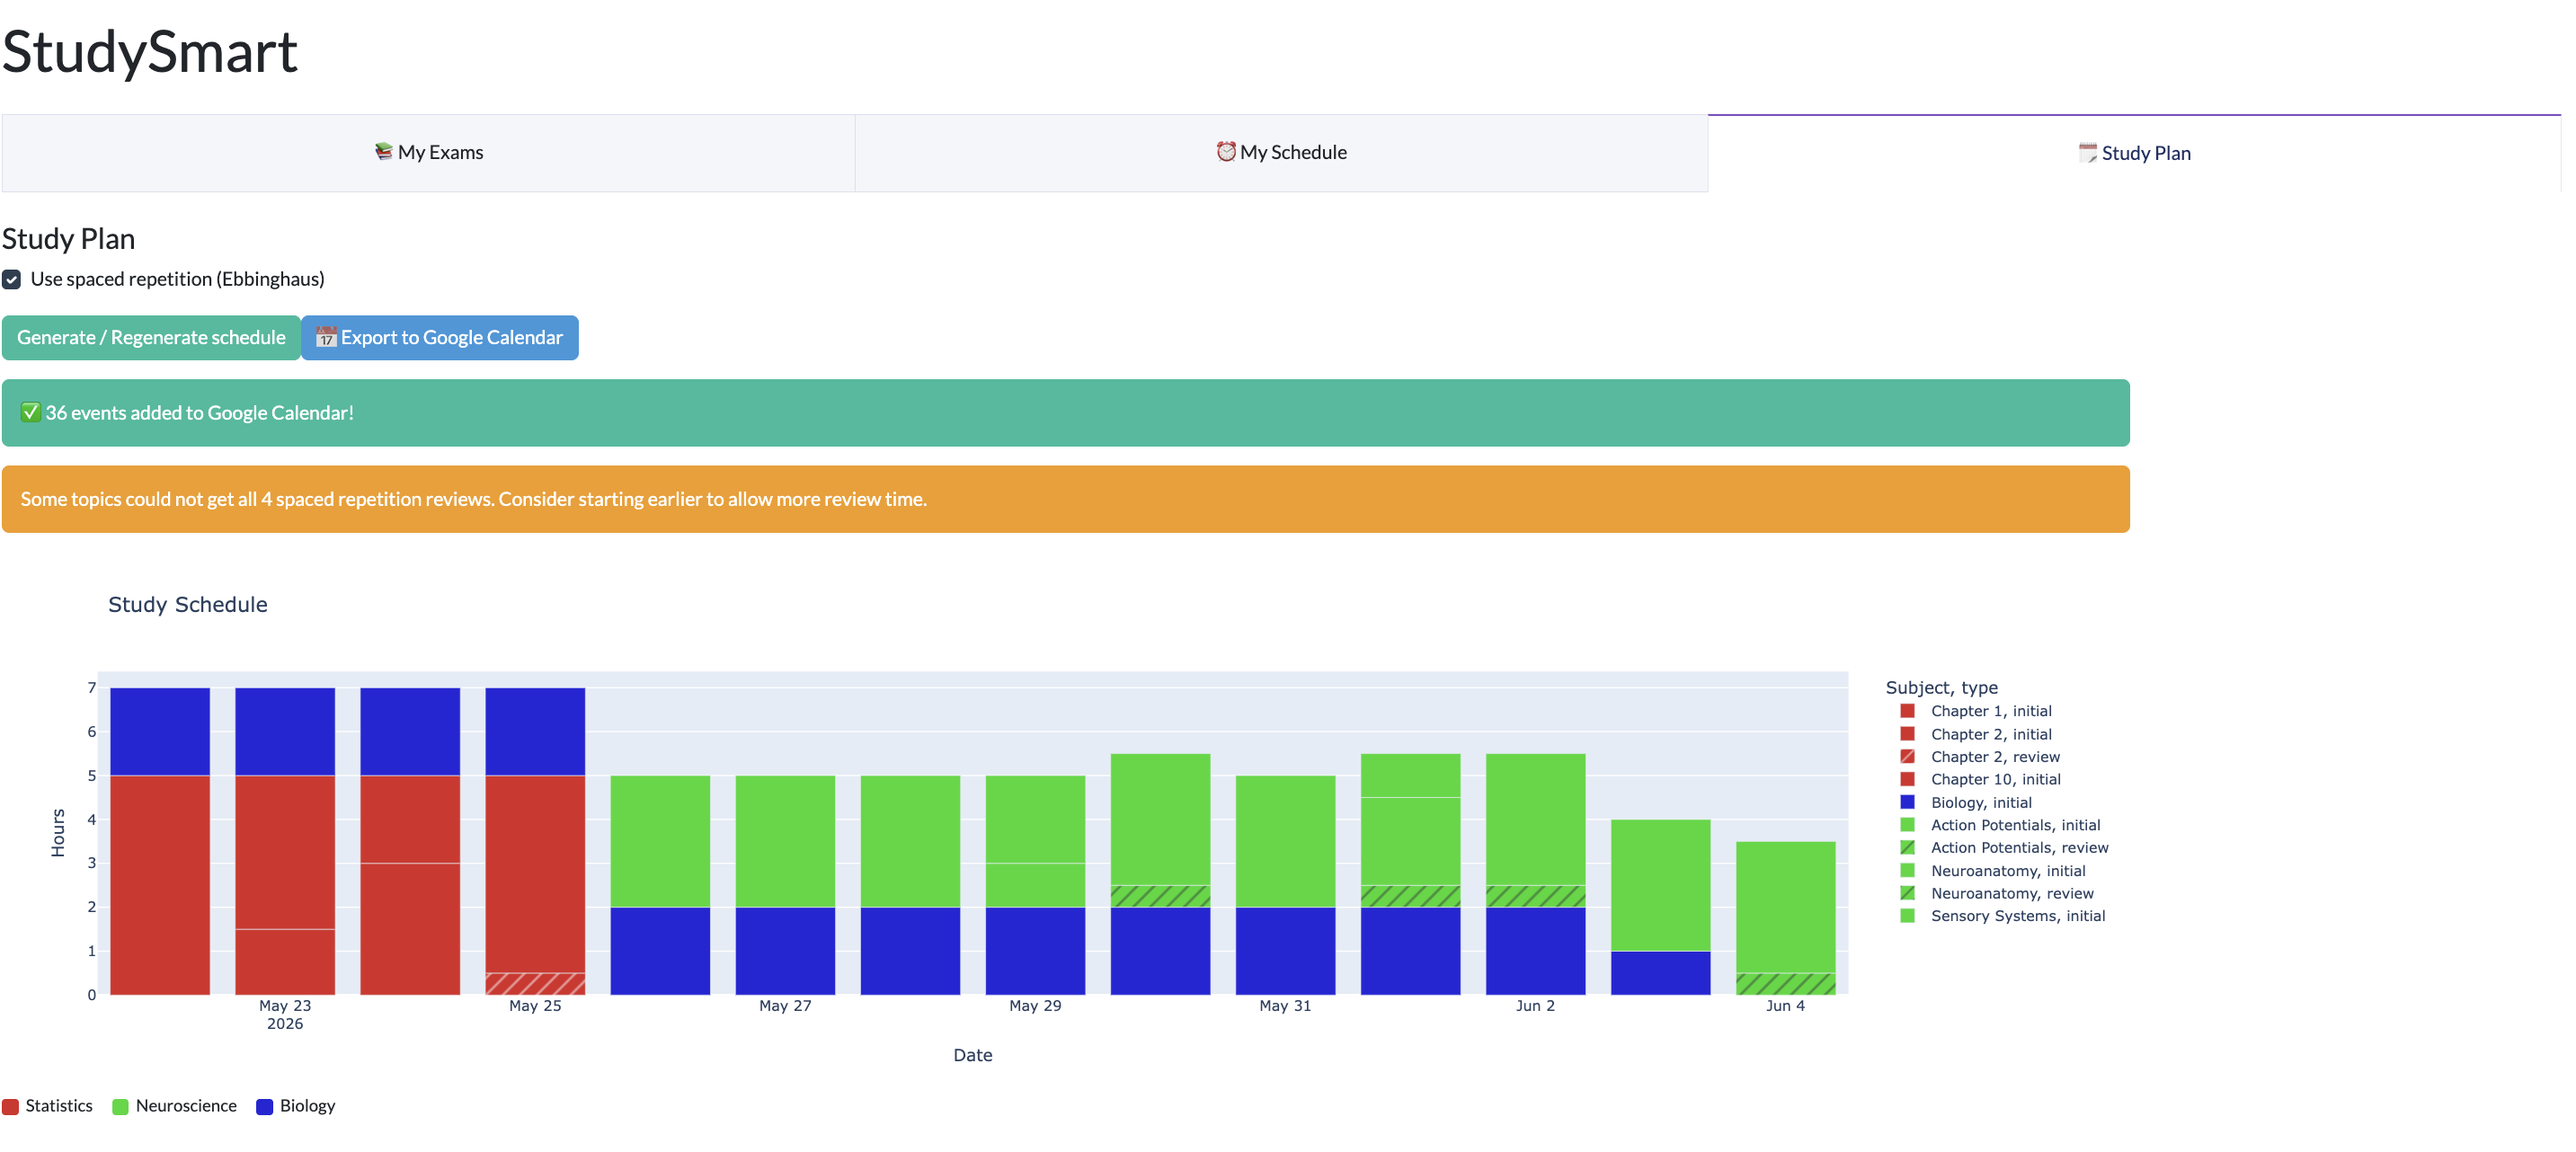


Google calendar view:

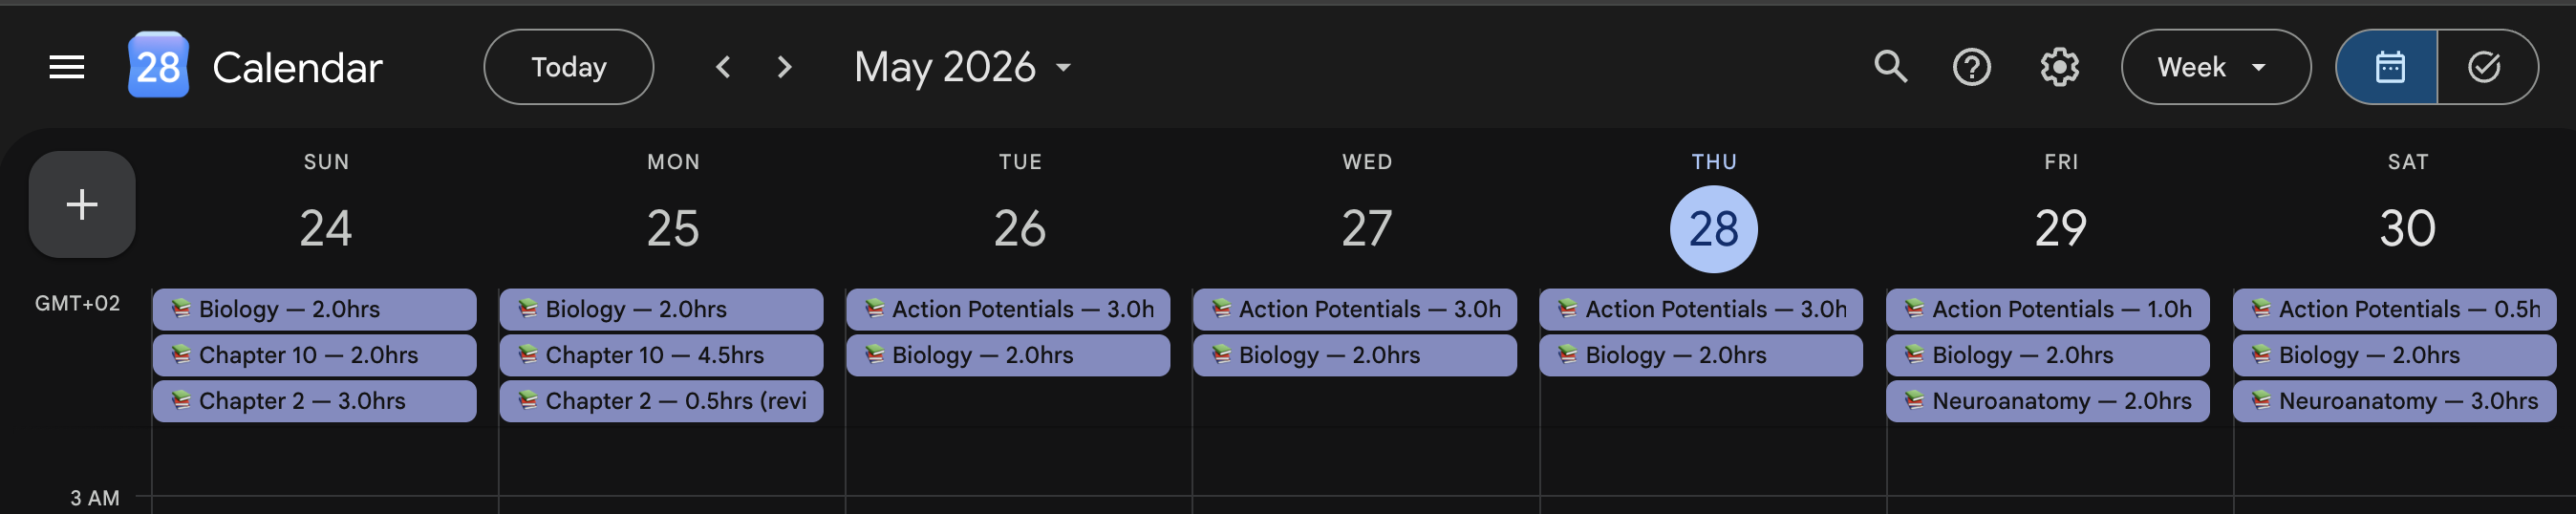


### **Regenerating Your Schedule**

Plans changed after generating your schedule? 

- **Add commitment** in **⏰ My Schedule** (e.g., work day on May 29th, and gym on May 27th)

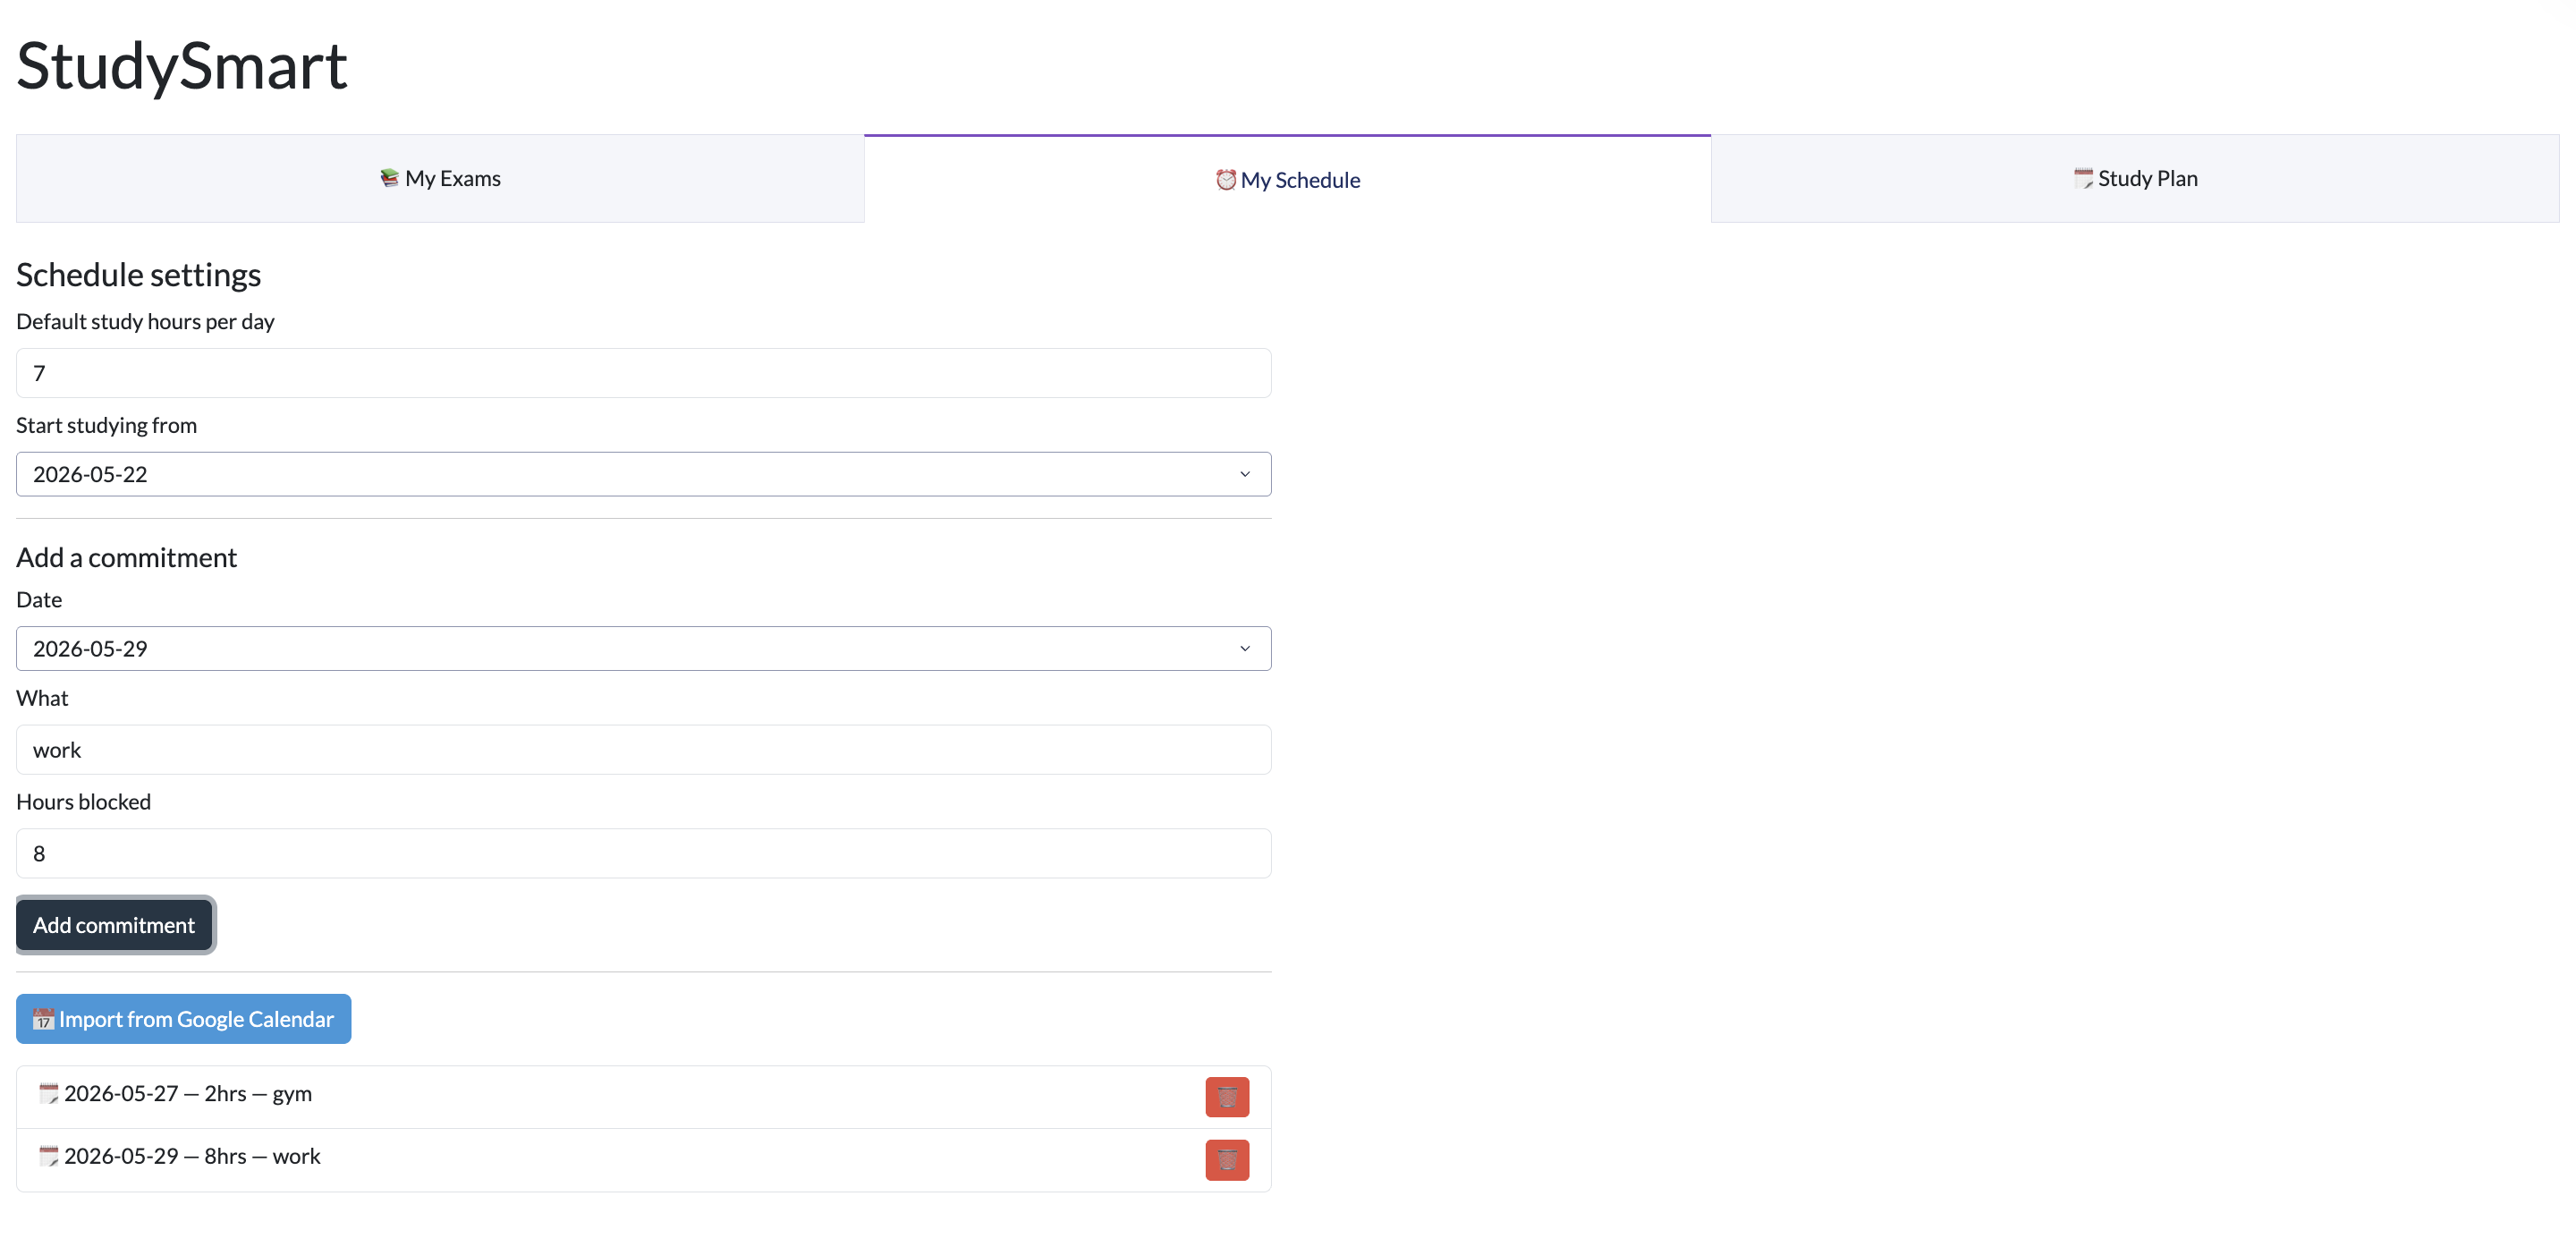





- Click **Generate / Regenerate Schedule** again in **🗓️ Study Plan** 

- View the new schedule and study tips with the new commitment taken into account (May 29th now has no study hours, May 27th does not change because there is still enough time in the day to study a predetermined amount (5 hrs))

> Note: regenerating your schedule rebuilds it entirely from scratch, so it works best when planned ahead before exam season starts, rather than adjusted day to day during exam preparations. 

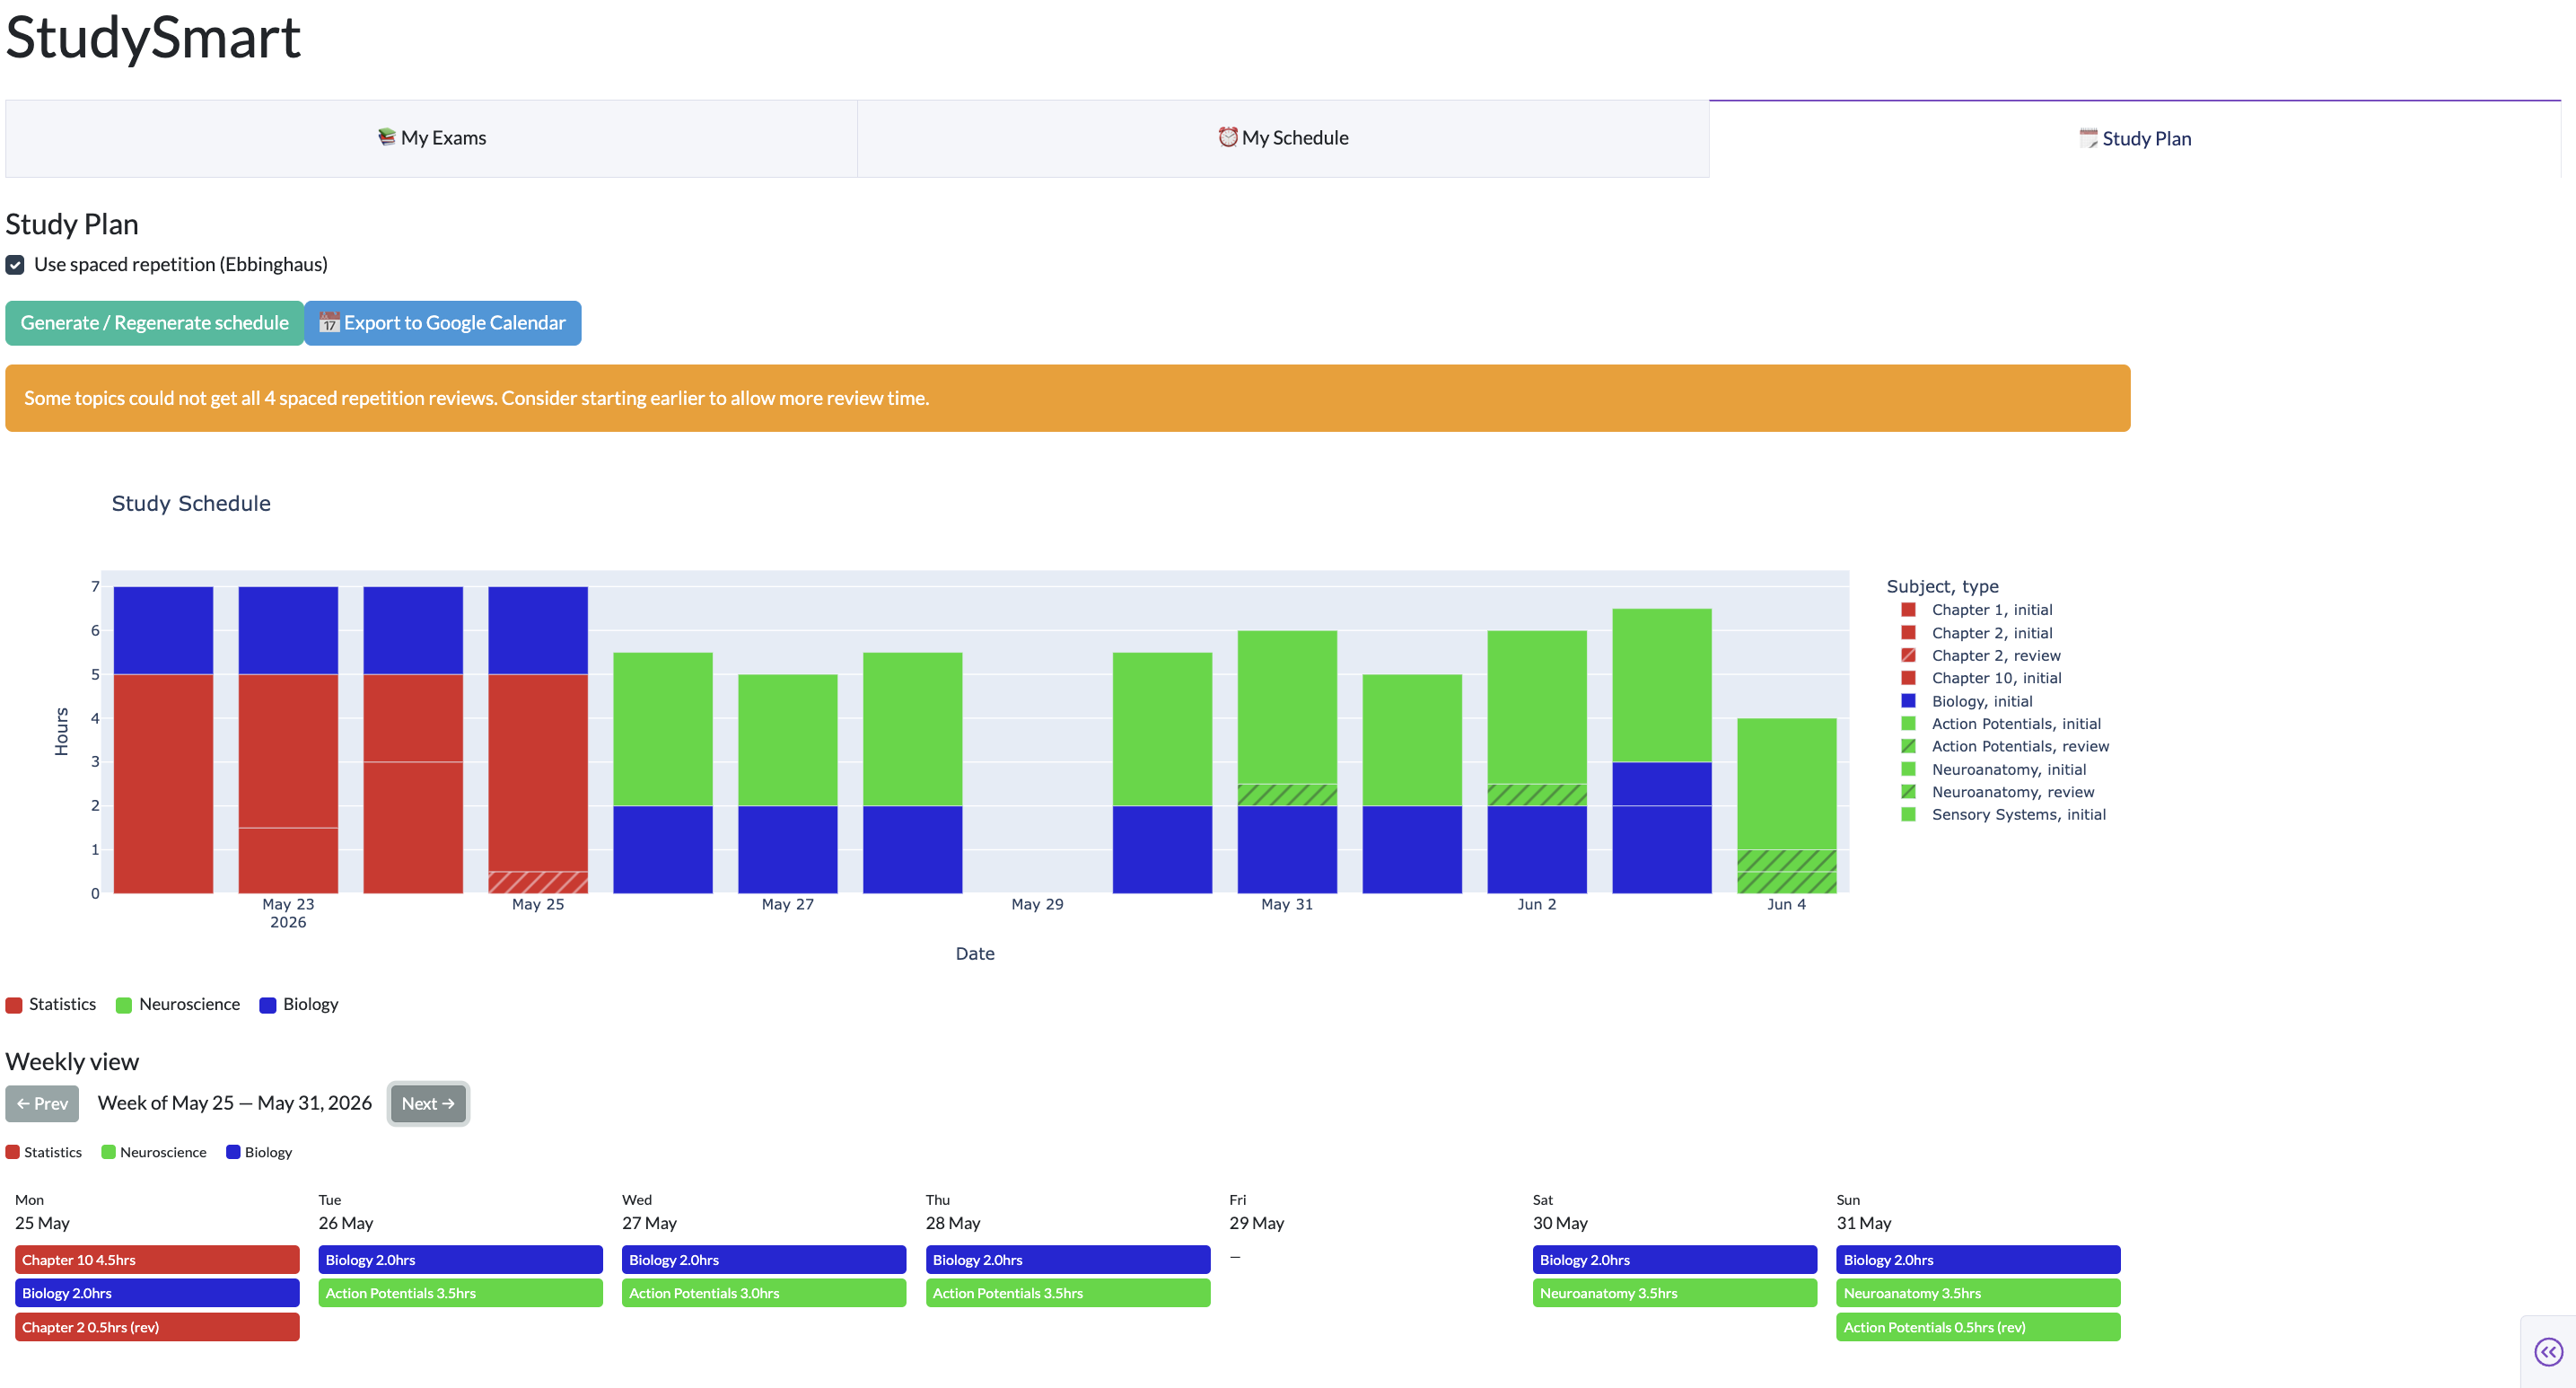



## References

 Craik, F. I. M., & Lockhart, R. S. (1972). Levels of processing: A framework for memory research. *Journal of Verbal Learning and Verbal Behavior, 11*(6), 671–684.

Ebbinghaus, H. (1885). *Über das Gedächtnis: Untersuchungen zur experimentellen Psychologie*. Duncker & Humblot.

Murre, J. M. J., & Dros, J. (2015). Replication and analysis of Ebbinghaus' forgetting curve. *PLOS ONE, 10*(7), e0120644. https://doi.org/10.1371/journal.pone.0120644

Roediger, H. L., & Karpicke, J. D. (2006). Test-enhanced learning. *Psychological Science, 17*(3), 249–255. https://doi.org/10.1111/j.1467-9280.2006.01693.x